# Building Knowledge Graphs with GLiNER2.5

**Entity and relation extraction for agent memory and document intelligence.**

This notebook builds two knowledge graphs from scratch with [GLiNER2.5](https://fastino.ai/models/gliner2-5) — a 194M-parameter
encoder that runs on a laptop CPU, needs no API key, and takes its extraction schema as a *runtime argument*
rather than a training decision.

Two graphs, because the two use cases pull in genuinely different directions:

| | **Agent memory** | **Document intelligence** |
|---|---|---|
| input | conversation episodes, arriving one at a time | a corpus, arriving at once |
| resolution | incremental — link each episode into what's known | batch — resolve the whole corpus together |
| time | facts expire; contradictions must supersede | facts are stamped, not superseded |
| the hard part | coreference (*"I"*, *"he"*, *"the migration"*) | alias variation (*NWL* / *Northwind* / *the Company*) |
| read pattern | every single turn, latency-critical | analytical, offline |

The through-line is the **ontology**: a declarative graph model — node labels, edge types, and which
`(head, RELATION, tail)` triples are legal — that drives extraction, constrains decoding, validates the
result, and generates the Cypher. Swap the extractor and the graph model survives.

---

### What this notebook is honest about

Small models fail in specific ways, and the failures are more instructive than the successes. Where the
corpora ship gold facts, the claims below are scored against them rather than eyeballed, and several of them
started out as the opposite claim:

- a 520-word transcript decoding to **12 relations** where a 400-word prefix of it yields 78 — with
  `feasible=True` and nothing in the returned object to say so, measured across all five sessions
- the temporal demo recovering **0 of 2** planted contradictions on the relation the corpus declares, and why
- `symmetric=True` returning nothing, with one line on stderr as the only signal
- embedding similarity **failing** to tell alternatives from unrelated pairs, and what to do instead
- alias mining buying blocking recall that never converts, on a corpus where embeddings already caught it
- the ontology-size ceiling costing latency and **not** recall, which is not what §4 assumed

---

### Setup

```bash
uv sync              # or: pip install -e ".[dev]"
uv run jupyter lab
```

First run downloads ~400 MB (GLiNER2.5-base) plus ~90 MB (a MiniLM sentence encoder) from Hugging Face.
Everything after that is local and offline-capable.

## 0. Environment guard

`gliner2` ships three schema classes with different vocabularies, and the 2.5 checkpoints are recent. Assert what we depend on before anything downloads, and print the signatures rather than trusting a blog post.

In [1]:
import sys, os, time, json, warnings, inspect
from pathlib import Path

# the notebook lives in notebooks/, the package in src/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

warnings.filterwarnings("ignore", category=FutureWarning)

import gliner2
import torch, transformers

print(f"gliner2       {gliner2.__version__}")
print(f"torch         {torch.__version__}")
print(f"transformers  {transformers.__version__}")
print(f"python        {sys.version.split()[0]}")

# the imports that actually matter: joint decoding + the boundary (2.5) head
import gliner2.joint_ie                       # ImportError => wheel too old for JointIE
from gliner2.models.boundary import engine    # ImportError => no 2.5 architecture
from gliner2.joint_ie import JointIE, JointIEConfig, JointSchema
from gliner2 import AutoExtractor, AttributeGroup

print("\nJointIE + boundary head available")
print("\nJointSchema.relation:")
print(" ", inspect.signature(JointSchema.relation))

gliner2       2.0.0
torch         2.13.0
transformers  4.57.6
python        3.12.12

JointIE + boundary head available

JointSchema.relation:
  (self, name, head, tail, description=None, *, threshold=None, candidate_threshold=None, directed=True, symmetric=False, inverse=None, allow_self=False, max_per_head=None, max_per_tail=None, **aliases)


In [2]:
from huggingface_hub import constants as hf_constants

MODEL_ID   = "fastino/gliner2.5-base-v1"    # 194M, English,       ~407 MB
FAST_MODEL = "fastino/gliner2.5-small-v1"   #  74M, English,       ~296 MB
MULTI      = "fastino/gliner2.5-multi-v1"   # 287M, multilingual,  ~594 MB

# FAST=True swaps in the 74M model for a smoke test. It is not a cheaper way to
# run this notebook: §15 measures it finding about half the relations, which moves
# the resolution numbers, the temporal demo and every support threshold below.
FAST = False
MODEL = FAST_MODEL if FAST else MODEL_ID

print(f"model:      {MODEL}")
print(f"HF cache:   {hf_constants.HF_HUB_CACHE}")
print(f"first run downloads ~{'296' if FAST else '407'} MB + ~90 MB (MiniLM for entity resolution)")
print("\nOffline reruns: pass local_files_only=True to GlinerExtractor(...)")

model:      fastino/gliner2.5-base-v1
HF cache:   /Users/lyonwj/.cache/huggingface/hub
first run downloads ~407 MB + ~90 MB (MiniLM for entity resolution)

Offline reruns: pass local_files_only=True to GlinerExtractor(...)


## 1. Why a small encoder at all

The case for GLiNER2.5 over an LLM call is entirely about the cost curve, and it only matters at volume.
One press release is cheap either way. A million of them, re-extracted every time you change the ontology,
is a different conversation — and agent memory is worse, because it runs on *every turn* and sits directly
in the user's latency budget.

What you give up is real and §15 lists it: this model cannot produce an entity that appears nowhere in the
text, resolve pronouns, tell an asserted sentence from a denied one, or reason about time. Note what is *not*
on that list — inferring a relation between two spans that are both present is something it does well, and
notebook 03 measures it doing so.

In [3]:
import kgx

t0 = time.time()
extractor = kgx.GlinerExtractor(MODEL)
print(extractor)

para = (
    "Northwind Logistics Inc. said Chief Executive Priya Raman will lead the integration of "
    "Cascade Freight Systems, the Seattle-based carrier it agreed to buy for $1.4 billion."
)

# warm up (first forward pass pays one-time setup), then time it
extractor.model.extract_entities(para, ["company"])
t = time.time()
out = extractor.model.extract_entities(
    para, ["company", "person", "role", "money", "location"],
    include_confidence=True, include_spans=True,
)
elapsed = time.time() - t

n_params = sum(p.numel() for p in extractor.model.parameters()) / 1e6
print(f"\n{n_params:.0f}M parameters, {elapsed*1000:.0f} ms for {len(para.split())} words on {extractor.model.device}")
print(json.dumps(out, indent=2)[:700])

<GlinerExtractor fastino/gliner2.5-base-v1 194M params loaded in 4.5s>

194M parameters, 39 ms for 26 words on cpu
{
  "entities": {
    "company": [
      {
        "text": "Northwind Logistics Inc.",
        "confidence": 0.9991430044174194,
        "start": 0,
        "end": 24
      },
      {
        "text": "Cascade Freight Systems",
        "confidence": 0.998248815536499,
        "start": 87,
        "end": 110
      }
    ],
    "person": [
      {
        "text": "Priya Raman",
        "confidence": 0.9952220320701599,
        "start": 46,
        "end": 57
      }
    ],
    "role": [
      {
        "text": "Chief Executive",
        "confidence": 0.9665588736534119,
        "start": 30,
        "end": 45
      }
    ],
    "money": [
      {
        "text": "$1.4 billion",
        "confidenc


## 2. Four extraction shapes, and the one that matters

GLiNER2.5 exposes four tasks through one schema interface. They all run through the same encoder, and a
multi-task schema evaluates them in a single forward pass.

Worth knowing before you build on the raw API: **the output shape changes depending on the flags you pass.**
`extract_relations` returns bare 2-tuples by default and `{"head": {...}, "tail": {...}}` dicts the moment
either `include_spans` or `include_confidence` is set. `entities` values are plain strings by default and
dicts with the flags. The `kgx` wrappers used from §4 onward normalise all of this into typed records, so
this section is the only place raw dicts appear.

In [4]:
model = extractor.model
text = ("Halcyon Semiconductor competes with Torrent Microsystems and supplies controller boards "
        "to Northwind's telematics unit from its Phoenix fab.")

print("── entities ──")
print(json.dumps(model.extract_entities(text, ["company", "product", "geography"]), indent=1))

print("\n── relations (no flags: bare tuples) ──")
print(model.extract_relations(text, ["competes_with", "supplies"]))

print("\n── relations (include_confidence=True: shape changes to dicts) ──")
print(json.dumps(model.extract_relations(text, ["competes_with", "supplies"],
                                         include_confidence=True), indent=1)[:520])

print("\n── classification ──")
print(model.classify_text(text, {"tone": ["neutral", "positive", "negative"]}, include_confidence=True))

── entities ──
{
 "entities": {
  "company": [
   "Halcyon Semiconductor",
   "Torrent Microsystems",
   "Northwind"
  ],
  "product": [
   "controller boards",
   "telematics unit"
  ],
  "geography": [
   "Phoenix"
  ]
 }
}

── relations (no flags: bare tuples) ──
{'relation_extraction': {'competes_with': [('Halcyon Semiconductor', 'Torrent Microsystems')], 'supplies': [('Halcyon Semiconductor', 'controller boards')]}}

── relations (include_confidence=True: shape changes to dicts) ──
{
 "relation_extraction": {
  "competes_with": [
   {
    "head": {
     "text": "Halcyon Semiconductor",
     "confidence": 0.9949170351028442
    },
    "tail": {
     "text": "Torrent Microsystems",
     "confidence": 0.9949170351028442
    }
   }
  ],
  "supplies": [
   {
    "head": {
     "text": "Halcyon Semiconductor",
     "confidence": 0.6702812910079956
    },
    "tail": {
     "text": "controller boards",
     "confidence": 0.6702812910079956
    }
   }
  ]
 }
}

── classification ──


{'tone': {'label': 'neutral', 'confidence': 0.9937259554862976}}


In [5]:
# Multi-task: entities + relations + classification in ONE forward pass.
schema = (model.create_schema()
          .entities(["company", "product", "geography"])
          .relations(["competes_with", "supplies"])
          .classification("tone", ["neutral", "positive", "negative"]))

print(json.dumps(model.extract(text, schema, include_confidence=True), indent=1)[:900])

{
 "entities": {
  "company": [
   {
    "text": "Halcyon Semiconductor",
    "confidence": 0.9997263550758362
   },
   {
    "text": "Torrent Microsystems",
    "confidence": 0.9993693232536316
   }
  ],
  "product": [
   {
    "text": "controller boards",
    "confidence": 0.9868069291114807
   },
   {
    "text": "telematics unit",
    "confidence": 0.92061448097229
   }
  ],
  "geography": [
   {
    "text": "Phoenix",
    "confidence": 0.9857389330863953
   }
  ]
 },
 "tone": {
  "label": "neutral",
  "confidence": 0.956169068813324
 },
 "relation_extraction": {
  "competes_with": [
   {
    "head": {
     "text": "Halcyon Semiconductor",
     "confidence": 0.9900262355804443
    },
    "tail": {
     "text": "Torrent Microsystems",
     "confidence": 0.9900262355804443
    }
   }
  ],
  "supplies": []
 }
}


### Span attributes: the qualifier channel

An entity span can carry classification labels of its own. This turns out to be load-bearing later —
typed edges in a graph schema have no properties, so anything that would naturally be an edge attribute
has to be recovered here and stored on the node instead.

The attribute head only fires on spans the entity head found, so the entity label has to work first. Run the
same text under a bare label and a description-style one to see how much that matters.

In [6]:
STANCE_TEXT = "Dev loves the graph model but is frustrated with the driver docs. He tolerates Java."

for label in ["tool", "a software tool, library, or product the user works with"]:
    attr_schema = (model.create_schema()
                   .entities([label])
                   .entity_attributes({
                       "stance": AttributeGroup(["likes", "dislikes", "neutral"], applies_to=[label])
                   }))
    print(f"── entity label: {label!r}")
    print(json.dumps(model.extract(STANCE_TEXT, attr_schema, include_confidence=True), indent=1))

── entity label: 'tool'


{
 "entities": {
  "tool": []
 }
}
── entity label: 'a software tool, library, or product the user works with'
{
 "entities": {
  "a software tool, library, or product the user works with": [
   {
    "text": "Java",
    "confidence": 0.9235374331474304,
    "stance": {
     "label": "neutral",
     "confidence": 0.8104321360588074
    }
   },
   {
    "text": "graph model",
    "confidence": 0.6209785342216492,
    "stance": {
     "label": "likes",
     "confidence": 0.9966841340065002
    }
   },
   {
    "text": "driver docs",
    "confidence": 0.5283473134040833,
    "stance": {
     "label": "dislikes",
     "confidence": 0.9946670532226562
    }
   }
  ]
 }
}


The bare label `"tool"` finds nothing, so the stance head has nothing to attach to and the whole pass returns
an empty dict. Reworded as a description it finds all three spans and labels them correctly — `graph model`
likes, `driver docs` dislikes, `Java` neutral — and the two spans that carry real sentiment get stance
confidences above 0.99, well above the 0.53 and 0.62 the entity head gave those same spans. The attribute is
more certain than the entity it hangs off.

Two things fall out of that. The mechanism works and is used on the corpus in §5. And label wording is not
cosmetic: it is the difference between this cell returning three qualified spans and returning nothing. §15
comes back to that with a proper probe.

## 3. The problem: relations extracted independently don't make a graph

`extract_relations` scores relations. `extract_entities` scores entities. Run separately, nothing guarantees
the two agree — a relation can be reported between spans that never cleared the entity threshold, or between
spans whose types make the edge meaningless.

Here is a paragraph engineered to show it. `works_for` should go *person → company*. Watch what happens when
the two tasks are asked separately.

In [7]:
tricky = ("Priya Raman joined Northwind Logistics in Seattle after five years at Cascade Freight. "
          "Berlin remains her home base, and the Fleet Telemetry Pipeline reports to her.")

print("entities:")
ents = model.extract_entities(tricky, ["person", "company", "location", "project"], include_spans=True)
for etype, items in ents["entities"].items():
    print(f"  {etype:10}", [i["text"] if isinstance(i, dict) else i for i in items])

print("\nrelations, extracted independently:")
rels = model.extract_relations(tricky, ["works_for", "located_in"], include_confidence=True)
for rtype, items in rels.get("relation_extraction", {}).items():
    for it in items:
        print(f"  {it['head']['text']!r:28} -{rtype}-> {it['tail']['text']!r}")

entities:
  person     ['Priya Raman']
  company    ['Cascade Freight', 'Northwind Logistics']
  location   ['Berlin', 'Seattle']
  project    ['Fleet Telemetry Pipeline']

relations, extracted independently:
  'Priya Raman'                -works_for-> 'Northwind Logistics'
  'Priya Raman'                -works_for-> 'Cascade Freight'
  'Priya Raman'                -located_in-> 'Seattle'


Nothing in that output is *typed*. `works_for` is emitted between whatever two spans scored well, and
checking whether the head is a person and the tail a company is left to you — after the fact, when the
model has already committed.

### JointIE decodes the graph instead

`JointIE` scores mention candidates and relation candidates together, then searches for a globally
consistent assignment: every edge connects two entities that are *in the result*, with endpoint types the
schema permits, satisfying the declared structural constraints.

The types stop being a post-filter and become part of what the model is optimising.

In [8]:
joint = JointIE.from_pretrained(MODEL)

typed = (JointSchema()
         .entity("person",  "a named human")
         .entity("company", "a business organization")
         .entity("location", "a city, region or country")
         .entity("project", "a named body of work")
         .relation("works_for", "person", "company", "the person is employed by the company")
         .relation("located_in", ["person", "company"], "location", "where the head is based"))

result = joint.extract(tricky, typed)

print(f"feasible={result.feasible}   {len(result.entities)} entities, {len(result.relations)} relations\n")
for e in result.entities:
    print(f"  {e.id:4} {e.type:10} {e.text!r:26} [{e.start}:{e.end}] {e.confidence:.3f}")
print()
for r in sorted(result.relations, key=lambda r: -r.confidence):
    print(f"  {result.entity(r.head).text!r:22} -[{r.type} {r.confidence:.2f}]-> {result.entity(r.tail).text!r}")

/Users/lyonwj/github/johnymontana/extraction-sandbox/.venv/lib/python3.12/site-packages/gliner2/models/boundary/model.py:2101: UserWarning: Checkpoint uses legacy list-valued extra_special_tokens metadata; loading with compatibility normalization.
  tokenizer = load_extractor_tokenizer(tokenizer_source)


/Users/lyonwj/github/johnymontana/extraction-sandbox/.venv/lib/python3.12/site-packages/gliner2/models/boundary/model.py:1147: RuntimeWarning: Encoder rejected attn_implementation='sdpa'; falling back to 'eager' (DebertaV2Model does not support an attention implementation through torch.nn.functional.scaled_dot_product_attention yet. Please request the support for this architecture: https://github.com/huggingface/transformers/issues/28005. If you believe this error is a bug, please open an issue in Transformers GitHub repository and load your model with the argument `attn_implementation="eager"` meanwhile. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="eager")`)
  self.encoder = self._load_encoder(


feasible=True   6 entities, 2 relations

  e1   person     'Priya Raman'              [0:11] 0.999
  e2   company    'Northwind Logistics'      [19:38] 0.999
  e3   location   'Seattle'                  [42:49] 1.000
  e4   company    'Cascade Freight'          [70:85] 1.000
  e5   location   'Berlin'                   [87:93] 1.000
  e6   project    'Fleet Telemetry Pipeline' [125:149] 0.998

  'Priya Raman'          -[works_for 0.98]-> 'Northwind Logistics'
  'Priya Raman'          -[located_in 0.86]-> 'Seattle'


Relations reference entities by **id** (`e1`, `e2`), not by surface string. That indirection is what makes
the output a graph: two mentions of "Northwind" in different sentences are different nodes with different
offsets, and an edge points at one specific occurrence. Resolving those occurrences into one entity is §7 —
and note it is a separate problem from extraction, deliberately.

In [9]:
print(json.dumps(result.to_dict(), indent=1)[:600])
print("\nresult.to_networkx() ->", result.to_networkx())

{
 "entities": [
  {
   "id": "e1",
   "type": "person",
   "text": "Priya Raman",
   "start": 0,
   "end": 11,
   "confidence": 0.9988954555329798
  },
  {
   "id": "e2",
   "type": "company",
   "text": "Northwind Logistics",
   "start": 19,
   "end": 38,
   "confidence": 0.9994463059437454
  },
  {
   "id": "e3",
   "type": "location",
   "text": "Seattle",
   "start": 42,
   "end": 49,
   "confidence": 0.9997101946884317
  },
  {
   "id": "e4",
   "type": "company",
   "text": "Cascade Freight",
   "start": 70,
   "end": 85,
   "confidence": 0.9998614221547254
  },
  {
   "id": "e5",
   "t

result.to_networkx() -> MultiDiGraph with 6 nodes and 2 edges


### Structural constraints, and one that is broken

Constraints are enforced *during* decoding, so they change which graph gets chosen rather than pruning a bad
one afterwards. `unique_head=True` on `works_for` means one employer per person; `acyclic=True` on `part_of`
means containment cannot loop.

One caveat found by testing rather than reading: **`symmetric=True` is broken in `gliner2` 2.0.0.** The
relation returns *nothing* — with `feasible=True`, so the empty result is indistinguishable from "this text
has no such relation" as far as the returned object is concerned. The cell below demonstrates it, and shows
the working alternative.

In [10]:
sym_text = "Alice collaborates with Bob on the migration. Acme Corp competes with Globex Inc."

for symmetric in (False, True):
    s = (JointSchema().entity("person", "a named human")
         .relation("collaborates_with", "person", "person", symmetric=symmetric))
    r = joint.extract(sym_text, s)
    triples = [(r.entity(x.head).text, x.type, r.entity(x.tail).text) for x in r.relations]
    print(f"symmetric={symmetric!s:5} feasible={r.feasible}  entities={len(r.entities)}  relations={len(r.relations)}  {triples}")

print("\n^ symmetric=True: entities found, zero relations, feasible=True.")
print("  The only signal is the gliner2 line on stderr above; the returned object says nothing.\n")

# The working way to get a mirrored edge: a directed relation plus `inverse=`.
# Endpoint types must be exact mirrors -- head(a) == tail(b) and tail(a) == head(b).
inv = (JointSchema().entity("person").entity("company")
       .relation("works_for", "person", "company")
       .relation("employs", "company", "person", inverse="works_for"))
r = joint.extract("Alice works for Acme Corp.", inv)
for x in r.relations:
    tag = "  [derived by inverse]" if x.derived else ""
    print(f"  {r.entity(x.head).text!r:12} -{x.type:11}-> {r.entity(x.tail).text!r}{tag}")

symmetric=False feasible=True  entities=2  relations=1  [('Alice', 'collaborates_with', 'Bob')]


greedy joint-IE decoding produced a constraint-violating assignment; returning empty solution


symmetric=True  feasible=True  entities=2  relations=0  []

^ symmetric=True: entities found, zero relations, feasible=True.
  The only signal is the gliner2 line on stderr above; the returned object says nothing.



  'Acme Corp'  -employs    -> 'Alice'  [derived by inverse]
  'Alice'      -works_for  -> 'Acme Corp'


Note what the stderr line says, because it is not what the schema-compilation story would predict: gliner2
reports that greedy decoding *produced a constraint-violating assignment and fell back to empty*, not that
every candidate edge was rejected up front. So the mechanism is a decode-time fallback. That distinction
matters if you were hoping to detect the case by inspecting the compiled schema — you cannot; you have to run
it. And a warning on stderr is not an error: it will not fail a pipeline, it will not appear in a log that
captures stdout only, and most notebook readers scroll past it.

> **Always check `result.feasible`.** When the constraint set is unsatisfiable, the decoder returns an empty
> assignment rather than raising. `feasible=False` means *"your schema is over-constrained"*; an empty result
> with `feasible=True` means *"no facts here"* — except when it means the fallback above fired, or when the
> input was too long (§11). Conflating them will cost you an afternoon. `kgx` warns on the over-constrained
> case and on the long-input case.

## 4. The ontology as code

Everything above built schemas inline. That does not survive contact with a real project: the same graph
model has to drive extraction, validate results, generate Cypher, and be reviewable by someone who does not
read Python.

`kgx.Ontology` is that model as data — node labels with annotation guidelines, edge types with typed
endpoints and constraints, and the set of legal `(head, RELATION, tail)` triples that falls out. It compiles
*to* a `JointSchema`; it is not one.

In [11]:
from kgx.ontology import Ontology, EntityType, RelationType

demo = Ontology(
    name="hiring",
    description="Toy ontology to show the shape",
    entities=(
        EntityType("person",  "A named human."),
        EntityType("company", "An employer, by name."),
        EntityType("role",    "A job title. Not a department."),
    ),
    relations=(
        RelationType("works_for", ("person",), ("company",),
                     "The person is employed by the company.", unique_head=True),
        RelationType("holds", ("person",), ("role",), "The person's job title."),
    ),
)

print(demo.summary())
print("\nlegal triples:", sorted(demo.patterns()))
print("\npermits(person, works_for, company) =", demo.permits("person", "works_for", "company"))
print("permits(company, works_for, person) =", demo.permits("company", "works_for", "person"))

Ontology 'hiring': 3 entity types, 2 relations, 2 legal triple patterns
  entities: person, company, role
  works_for          person                       -> company  [unique_head]
  holds              person                       -> role

legal triples: [('person', 'holds', 'role'), ('person', 'works_for', 'company')]

permits(person, works_for, company) = True
permits(company, works_for, person) = False


The ontology is JSON round-trippable, so it can live in a config file, be diffed in review, or be generated.
Nothing about the graph model is trapped in Python.

In [12]:
blob = demo.to_json()
print(blob[:420], "...\n")
assert Ontology.from_dict(json.loads(blob)).patterns() == demo.patterns()
print("round-trip OK")

# Malformed ontologies fail at construction, not at inference time.
for label, thunk in [
    ("relation references an undeclared entity type",
     lambda: Ontology(name="x", entities=(EntityType("person"),),
                      relations=(RelationType("works_for", ("person",), ("company",)),))),
    ("inverse endpoints are not mirrored",
     lambda: Ontology(name="x", entities=(EntityType("person"), EntityType("company")),
                      relations=(RelationType("works_for", ("person",), ("company",)),
                                 RelationType("employs", ("company",), ("person",), inverse="nope")))),
]:
    try:
        thunk()
        print(f"  {label}: NO ERROR (unexpected)")
    except (ValueError, KeyError) as exc:
        print(f"  {label}:\n      {type(exc).__name__}: {exc}")

{
  "name": "hiring",
  "description": "Toy ontology to show the shape",
  "no_self_loops": true,
  "entities": [
    {
      "name": "person",
      "description": "A named human."
    },
    {
      "name": "company",
      "description": "An employer, by name."
    },
    {
      "name": "role",
      "description": "A job title. Not a department."
    }
  ],
  "relations": [
    {
      "name": "works_for",
      ...

round-trip OK
  relation references an undeclared entity type:
      ValueError: relation 'works_for' references undeclared entity types: ['company']
  inverse endpoints are not mirrored:
      KeyError: "unknown relation 'nope'"


### The two shipped ontologies

`kgx` ships one for each use case. Both are 13 node labels and 15–16 edge types, chosen on the theory that
**every type name and description is serialised into the encoder input on every call**, so a sprawling
ontology should cost both context budget and recall. §5 measures that, and half of it turns out to be wrong.

Two modelling decisions in the agent-memory ontology are worth arguing about, because they are adaptations
forced by the tool rather than by the domain:

1. **`prefers` and `avoids` are separate relations**, not one edge with a polarity property. `JointSchema`
   edges carry no attributes, so a polarity has nowhere to live.
2. **`constraint` is a node, not an edge.** Every hard rule binding the user is then one label lookup, no
   traversal — which is what prompt assembly needs on each turn.

In [13]:
print(kgx.AGENT_MEMORY.summary())

Ontology 'agent_memory': 13 entity types, 16 relations, 69 legal triple patterns
  entities: user, person, organization, project, task, goal, constraint, tool, skill, event, place, artifact, topic
  works_at           user|person                  -> organization
  works_on           user|person                  -> project
  assigned_to        task                         -> user|person  [unique_head]
  part_of            task|project                 -> project|organization  [unique_head]  [acyclic]
  collaborates_with  user|person                  -> user|person
  prefers            user                         -> tool|topic|organization|place
  avoids             user                         -> tool|topic|organization|place
  has_constraint     user|person|project|organization -> constraint
  pursues            user|person|project          -> goal
  uses_tool          user|person|project          -> tool
  has_skill          user|person                  -> skill
  attended           u

In [14]:
print(kgx.BUSINESS_NEWS.summary())

Ontology 'business_news': 13 entity types, 15 relations, 52 legal triple patterns
  entities: company, person, regulator, product, business_segment, geography, sector, security, financial_metric, risk_factor, litigation, business_event, commodity
  subsidiary_of      company                      -> company  [unique_head]  [acyclic]
  officer_of         person                       -> company|regulator  [unique_head]
  acquires           company                      -> company|business_segment|product  [acyclic]
  has_stake_in       company|person               -> company|security
  supplies           company|commodity            -> company
  partners_with      company                      -> company|regulator
  competes_with      company                      -> company
  operates_in        company|business_segment     -> geography|sector
  produces           company|business_segment     -> product|commodity
  reports_metric     company|business_segment     -> financial_metric
  faces_r

`to_mermaid()` renders the *model* — the type-level graph, not the data. This is the diagram to put in front
of a domain expert before extracting anything, and the cheapest place to catch a modelling mistake.

In [15]:
from IPython.display import Markdown, display

sub = kgx.AGENT_MEMORY.subset(
    entities=["user", "person", "organization", "project", "tool", "constraint", "place"],
    relations=["works_at", "works_on", "collaborates_with", "prefers", "avoids",
               "has_constraint", "uses_tool", "located_in"],
    name="agent_memory_core",
)
print(sub.summary(), "\n")

display(Markdown("```mermaid\n" + sub.to_mermaid() + "\n```"))

Ontology 'agent_memory_core': 7 entity types, 8 relations, 24 legal triple patterns
  entities: user, person, organization, project, constraint, tool, place
  works_at           user|person                  -> organization
  works_on           user|person                  -> project
  collaborates_with  user|person                  -> user|person
  prefers            user                         -> tool|organization|place
  avoids             user                         -> tool|organization|place
  has_constraint     user|person|project|organization -> constraint
  uses_tool          user|person|project          -> tool
  located_in         user|person|organization     -> place  [unique_head] 



```mermaid
graph LR
  user([user])
  person([person])
  organization([organization])
  project([project])
  constraint([constraint])
  tool([tool])
  place([place])
  user -->|works_at| organization
  person -->|works_at| organization
  user -->|works_on| project
  person -->|works_on| project
  user -->|collaborates_with| user
  user -->|collaborates_with| person
  person -->|collaborates_with| user
  person -->|collaborates_with| person
  user -->|prefers| tool
  user -->|prefers| organization
  user -->|prefers| place
  user -->|avoids| tool
  user -->|avoids| organization
  user -->|avoids| place
  user -->|has_constraint| constraint
  person -->|has_constraint| constraint
  project -->|has_constraint| constraint
  organization -->|has_constraint| constraint
  user -->|uses_tool| tool
  person -->|uses_tool| tool
  project -->|uses_tool| tool
  user -->|located_in| place
  person -->|located_in| place
  organization -->|located_in| place
```

### Constraints changing the answer

`unique_head=True` is not a filter. It tells the decoder that at most one edge of this type may leave each
head node, and the search then has to *choose*. The natural expectation is that the survivor is whichever
edge best fits the whole assignment rather than the top local score. Two texts, one with two candidate
owners and one with a single owner, to see whether that is what happens.

In [16]:
# Two texts. The first states a handover, so `assigned_to` has two candidate tails
# out of one head; the second only ever names one owner.
PROBES = {
    "two owners": "The cutover was assigned to Dev Shah in March and reassigned to Tomás Ferreira in April.",
    "one owner":  ("The cutover task was originally assigned to Dev Shah, but Tomás Ferreira picked it up "
                   "last week after Dev moved to the telemetry work."),
}

for label, amb in PROBES.items():
    print(f"── {label}")
    for unique in (False, True):
        s = (JointSchema()
             .entity("task", "a discrete actionable item")
             .entity("person", "a named human")
             .relation("assigned_to", "task", "person", "the task is owned by this person",
                       unique_head=unique))
        r = joint.extract(amb, s)
        got = [(r.entity(x.head).text, round(x.confidence, 2), r.entity(x.tail).text) for x in r.relations]
        print(f"   unique_head={unique!s:5} feasible={r.feasible} -> {got}")

── two owners
   unique_head=False feasible=True -> [('cutover', 0.56, 'Dev Shah'), ('cutover', 0.73, 'Tomás Ferreira')]
   unique_head=True  feasible=True -> [('cutover', 0.73, 'Tomás Ferreira')]
── one owner


   unique_head=False feasible=True -> [('cutover', 0.82, 'Dev Shah')]


   unique_head=True  feasible=True -> [('cutover', 0.82, 'Dev Shah')]


The constraint changes the answer on the first text. Unconstrained, two edges leave `cutover` — Dev Shah at
0.56 and Tomás Ferreira at 0.73. Add `unique_head` and one survives, Tomás Ferreira at 0.73, with
`feasible=True` and nothing on stderr. The decoder pruned rather than gave up, and it kept the edge the
sentence supports: Dev had it in March, Tomás was reassigned it in April.

What the probe does *not* establish is why that edge. Here the globally consistent choice and the top local
score are the same edge, so the text cannot separate the two explanations. Distinguishing them needs a case
where the best single edge and the best whole assignment disagree, which two sentences will not construct.
Read the result narrowly: the constraint restricted the search, and the search returned a legal answer.

On the second text nothing changes at all — the decoder's preferred assignment already had one edge, so there
was nothing to choose between. That is the ordinary case, and it is why the second probe is worth leaving in:
a constraint is not a transformation applied to the output, it is a restriction on the search that shows up
only when the unrestricted optimum violates it.

That is the benign outcome and it is not the only one on offer. §3's `symmetric=True` is the same decoder
under a constraint it cannot satisfy, and there it returns **nothing** — `feasible=True`, one line on stderr,
no other signal. `AGENT_MEMORY` declares `unique_head` on `assigned_to` and on `located_in`, so both
behaviours are live in this notebook. **Check `feasible` and check the count**; `feasible=True` with zero
edges is not "no facts here".

Worth noticing separately: on the second text the model picks **Dev Shah**, and the sentence says Tomás
Ferreira picked the task up after Dev moved off it. `unique_head` has no opinion about that. It bounds the
*shape* of the graph, never the correctness of an edge — a wrong edge that satisfies the constraint sails
through, which is the same lesson §9 arrives at from the other direction.

---

# Use case A — Document intelligence

A corpus of ten short business-news documents about an interlocking set of fictional companies: an
acquisition, a partnership, a competitive dynamic, a supply chain, a regulatory investigation, a guidance
cut. Roughly 2,300 words total.

The corpus is written to be *awkward on purpose*. The same company appears as `Northwind Logistics Inc.`,
`Northwind Logistics`, `Northwind`, `NWL`, and `the Company`. There are sentences that read like facts and
are not: *"we may face supply disruptions if tariffs rise"*, *"management has no plans to divest"*. Both
traps are the point.

In [17]:
from kgx.data.documents import DOCUMENTS, ALIAS_GROUPS, MODALITY_TRAPS, GOLD_DOC_FACTS
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 46)

print(f"{len(DOCUMENTS)} documents, {sum(len(d['text'].split()) for d in DOCUMENTS)} words, "
      f"{len(ALIAS_GROUPS)} entities with alias variants, {len(MODALITY_TRAPS)} modality traps\n")
display(pd.DataFrame([{"doc_id": d["doc_id"], "date": d["date"], "source": d["source"],
                       "words": len(d["text"].split()), "title": d["title"]} for d in DOCUMENTS]))
print("\n" + DOCUMENTS[0]["text"][:420] + " ...")

10 documents, 2284 words, 13 entities with alias variants, 11 modality traps



,doc_id,date,source,words,title
0,d01,2026-01-14,Press Release,229,Northwind Logistics to Acquire Cascade Fre...
1,d02,2026-02-03,Reuters,225,US regulator opens review of Northwind-Cas...
2,d03,2026-02-19,8-K Excerpt,215,Northwind Logistics Inc. Form 8-K — Item 5...
3,d04,2026-03-05,Earnings Call Transcript,339,Northwind Logistics Inc. Fourth Quarter an...
4,d05,2026-03-26,Press Release,208,Halcyon Semiconductor Names Ana Duarte Chi...
5,d06,2026-04-15,Reuters,218,EU opens antitrust inquiry into Halcyon as...
6,d07,2026-05-07,8-K Excerpt,207,Northwind Logistics Inc. Form 8-K — Item 8...
7,d08,2026-05-21,Press Release,200,Vantage Energy Partners Signs Three-Year F...
8,d09,2026-06-11,Reuters,211,Northwind cuts 2026 guidance as diesel cos...
9,d10,2026-07-02,Earnings Call Transcript,232,Halcyon Semiconductor Corporation Second Q...



SEATTLE — Northwind Logistics Inc. (NASDAQ: NWL) today announced that it has entered into a definitive agreement to acquire Cascade Freight Systems for $1.4 billion in cash and stock. Under the terms of the agreement, Cascade Freight shareholders will receive $28.50 per share, a 22% premium to the thirty-day volume weighted average price.

Cascade Freight Systems operates 41 cross-dock terminals across the Pacific No ...


## 5. Extracting the corpus

One batched forward pass per batch of 8, against the `BUSINESS_NEWS` ontology.

In [18]:
t = time.time()
doc_graphs = extractor.extract_batch(DOCUMENTS, kgx.BUSINESS_NEWS)
elapsed = time.time() - t

n_mentions = sum(len(g.mentions) for g in doc_graphs)
n_edges = sum(len(g.edges) for g in doc_graphs)
infeasible = [g.doc_id for g in doc_graphs if not g.feasible]

print(f"{len(doc_graphs)} documents in {elapsed:.1f}s  ({elapsed/len(doc_graphs)*1000:.0f} ms/doc, CPU)")
print(f"{n_mentions} mentions, {n_edges} edges")
print(f"infeasible: {infeasible or 'none'}")

# The ontology check that fails when relations are extracted independently of entities.
violations = [v for g in doc_graphs for v in g.validate(kgx.BUSINESS_NEWS)]
print(f"edges violating the ontology's endpoint types: {len(violations)}")

10 documents in 7.0s  (699 ms/doc, CPU)
214 mentions, 170 edges
infeasible: none
edges violating the ontology's endpoint types: 0


Zero — but read the check before reading the result. `DocGraph.validate()` tests **endpoint types only**: for
every edge, is `(head.type, relation, tail.type)` one of the ontology's legal patterns. It does not test
`unique_head`, `acyclic` or `no_self_loops`, all of which `AGENT_MEMORY` declares and all of which get
violated later in this notebook (§14 shows the user holding three concurrent `located_in` values against a
relation marked `[unique_head]`). Every violation count printed in this notebook is an endpoint-type count and
is labelled as one; none of them is evidence that a structural constraint held.

Zero against what, though? A count with no baseline is not a payoff. Run the same corpus through the
independent path — `extract_entities` and `extract_relations` as separate calls, which is the API most
people reach for first — and check the same property.

In [19]:
# The baseline: entities and relations scored separately, then joined by surface
# string, which is all you can do when the relation output has no entity ids.
ent_labels = [e.name for e in kgx.BUSINESS_NEWS.entities]
rel_labels = [r.name for r in kgx.BUSINESS_NEWS.relations]

ind_edges = ind_bad = ind_unanchored = 0
t = time.time()
for d in DOCUMENTS:
    ents = extractor.model.extract_entities(d["text"], ent_labels, include_confidence=True)
    type_of = {}
    for etype, items in (ents.get("entities") or {}).items():
        for i in items:
            type_of.setdefault((i["text"] if isinstance(i, dict) else i).strip(), etype)

    rels = extractor.model.extract_relations(d["text"], rel_labels, include_confidence=True)
    for rtype, items in (rels.get("relation_extraction") or {}).items():
        for it in items:
            head, tail = it["head"]["text"].strip(), it["tail"]["text"].strip()
            ind_edges += 1
            ht, tt = type_of.get(head), type_of.get(tail)
            if ht is None or tt is None:
                ind_unanchored += 1
                ind_bad += 1
            elif not kgx.BUSINESS_NEWS.permits(ht, rtype, tt):
                ind_bad += 1

print(f"independent extraction: {ind_edges} edges in {time.time()-t:.1f}s")
print(f"  {ind_bad} violate the ontology ({ind_bad/ind_edges:.0%})")
print(f"  of those, {ind_unanchored} have an endpoint that never cleared the entity pass at all")
print(f"\njoint decoding:         {n_edges} edges, {len(violations)} violations")

independent extraction: 134 edges in 2.0s
  80 violate the ontology (60%)
  of those, 63 have an endpoint that never cleared the entity pass at all

joint decoding:         170 edges, 0 violations


That is the concrete payoff of joint decoding, and now it is a number rather than a claim. The independent
path puts the majority of its edges outside the graph model, and most of those are not subtle type confusions
— they are edges between spans that never became entities, so there is no node for them to attach to. Joint
decoding produces zero of both because endpoint types are a decoding constraint rather than a post-filter.

It does not make the edges *correct*. Several below are wrong. But every wrong edge is a judgement error you
can look at, rather than a type error you have to write a post-filter for.

In [20]:
from kgx.evaluate import score_triples, MatchPolicy

# 47 hand-written gold triples ship with the corpus. Score the raw surface triples
# now; §7 scores the resolved graph and the difference is what resolution buys.
# MatchPolicy here matches notebook 03's LENIENT: normalised names + the alias table.
POLICY = MatchPolicy(normalize_names=True, use_aliases=True)
surface_triples = sorted({(g.mention(e.head).text, e.type, g.mention(e.tail).text)
                          for g in doc_graphs for e in g.edges})
raw_score = score_triples(surface_triples, GOLD_DOC_FACTS, policy=POLICY, aliases=ALIAS_GROUPS)
print(f"{len(surface_triples)} distinct surface triples vs {len(GOLD_DOC_FACTS)} gold facts")
print(f"  precision {raw_score.precision:.3f}   recall {raw_score.recall:.3f}   F1 {raw_score.f1:.3f}")
print(f"  matched {len(raw_score.matched)}, missed {len(raw_score.missed)}, unmatched predictions {len(raw_score.spurious)}")

95 distinct surface triples vs 47 gold facts
  precision 0.200   recall 0.404   F1 0.268
  matched 19, missed 28, unmatched predictions 76


Two caveats that bound every score in this notebook, and they pull in opposite directions.

`GOLD_DOC_FACTS` is 47 hand-written triples and the ten documents plainly contain more than 47 true facts, so
an unmatched prediction is often true-and-unlabelled. **Precision here is a lower bound, not an estimate**,
and a system that emits more triples is penalised for volume. Recall is the trustworthy half. Notebook 03
hits the same wall and says the same thing.

And 47 gold facts is small. A few points of F1 is a handful of triples, so treat these numbers as a
regression check — something that moves when you break the pipeline — not as a benchmark result.

In [21]:
from kgx.extract import edges_frame, mentions_frame

edf = edges_frame(doc_graphs)
mdf = mentions_frame(doc_graphs)

print("mentions by type:")
print(mdf["type"].value_counts().to_string())
print("\nedges by relation:")
print(edf["relation"].value_counts().to_string())
print(f"\ndistinct surface triples: {edf[['head','relation','tail']].drop_duplicates().shape[0]} of {len(edf)} raw edges")
display(edf.sort_values("confidence", ascending=False).head(12))

mentions by type:
type
company             47
geography           35
financial_metric    27
person              20
product             15
business_segment    12
security            11
regulator           11
commodity           11
sector              10
business_event       9
risk_factor          6

edges by relation:
relation
operates_in       30
reports_metric    30
produces          27
partners_with     18
officer_of        17
participant_in    16
competes_with      9
faces_risk         9
acquires           7
subsidiary_of      6
impacts            1

distinct surface triples: 95 of 170 raw edges


,doc_id,head_id,head,head_type,relation,tail_id,tail,tail_type,confidence,derived
99,d06,d06:e8,Halcyon,company,operates_in,d06:e25,Germany,geography,0.9768,False
96,d06,d06:e24,Halcyon,company,operates_in,d06:e25,Germany,geography,0.9767,False
128,d08,d08:e1,Vantage Energy Partners,company,partners_with,d08:e3,Northwind Logistics Inc.,company,0.9750,False
161,d10,d10:e19,Halcyon,company,competes_with,d10:e14,Torrent Microsystems,company,0.9730,False
153,d09,d09:e11,Marcus Webb,person,officer_of,d09:e2,Northwind Logistics,company,0.9725,False
98,d06,d06:e6,Halcyon,company,operates_in,d06:e25,Germany,geography,0.9698,False
130,d08,d08:e7,Vantage Energy Partners,company,partners_with,d08:e3,Northwind Logistics Inc.,company,0.9687,False
95,d06,d06:e12,Halcyon,company,operates_in,d06:e25,Germany,geography,0.9660,False
115,d08,d08:e18,Dana Okonkwo,person,officer_of,d08:e1,Vantage Energy Partners,company,0.9644,False
116,d08,d08:e20,Marcus Webb,person,officer_of,d08:e7,Vantage Energy Partners,company,0.9620,False


Two problems are already visible in that table, and they are the two halves of the rest of this notebook:

1. **The same fact appears many times.** *Northwind acquires Cascade* is asserted once per sentence that
   mentions it, each time between a *different pair of mention ids*. The raw edge count measures sentences,
   not facts.
2. **The same entity appears under several names.** `Northwind`, `Northwind Logistics Inc.` and `NWL` are
   three different nodes right now.

Before fixing either, one more extraction concern.

### The modality trap

Filings and press releases are full of sentences that are grammatically assertions and semantically not.
Extract them naively and the graph confidently reports a supply disruption that never happened.

`impacts` and `faces_risk` in the ontology deliberately do **not** split into
`negatively_impacts` / `may_impact` / `does_not_impact`. Predicate explosion costs encoder budget and hurts
recall on all of them. Instead, a second span-attribute pass tags the *node* with its modality, and every
downstream query filters on it.

In [22]:
for trap in MODALITY_TRAPS[:5]:
    print(f"  [{trap['doc_id']}] {trap['sentence'][:110]}")
    print(f"          -> {trap['why']}")

  [d01] The proposed acquisition, if approved by the Surface Transportation Board, would add roughly 9,000 lane-miles 
          -> hypothetical - conditional on regulatory approval, and forward-looking
  [d01] The Company does not expect to acquire additional terminal assets in 2026.
          -> negated expectation - no acquisition relation should be asserted
  [d02] Management has no plans to divest the Cascade brand, or to fold its terminals into Northwind's existing networ
          -> negated intent - a divestiture is denied, not announced
  [d03] We may face supply disruptions if tariffs on imported semiconductor components rise, because a single vendor, 
          -> mixed - the supplies(Torrent, Northwind) clause IS asserted, but the disruption is hypothetical and conditional on tariffs rising
  [d03] Should demand for expedited freight soften, margins in our Freight Brokerage segment could compress meaningful
          -> hypothetical - inverted conditional; no margin compres

In [23]:
MODALITY = ["asserted", "forecast", "hypothetical", "negated"]
QUALIFIED_TYPES = ["business_event", "risk_factor", "financial_metric"]

t = time.time()
doc_graphs = [
    extractor.qualify(g, {"modality": MODALITY}, applies_to={"modality": QUALIFIED_TYPES})
    for g in doc_graphs
]
print(f"qualifier pass: {time.time()-t:.1f}s\n")

rows = [{"doc_id": g.doc_id, "type": m.type, "text": m.text,
         "modality": m.attrs["modality"]["label"],
         "conf": round(m.attrs["modality"]["confidence"], 2)}
        for g in doc_graphs for m in g.mentions if "modality" in m.attrs]
qdf = pd.DataFrame(rows)
print(qdf["modality"].value_counts().to_string())
display(qdf[qdf.modality != "asserted"].sort_values("conf", ascending=False).head(12))

qualifier pass: 0.8s

modality
forecast        12
hypothetical     4
asserted         3
negated          1


,doc_id,type,text,modality,conf
5,d03,financial_metric,margins,hypothetical,0.57
2,d01,financial_metric,adjusted earnings per share,forecast,0.56
13,d07,business_event,Cascade Freight transaction,hypothetical,0.56
3,d01,financial_metric,annual run-rate synergies,forecast,0.54
6,d04,financial_metric,Adjusted operating margin,forecast,0.51
9,d04,financial_metric,adjusted operating margin,forecast,0.51
4,d01,business_event,transaction,forecast,0.50
1,d01,business_event,transaction,forecast,0.50
17,d10,financial_metric,non-GAAP gross margin,forecast,0.48
7,d04,financial_metric,free cash flow,forecast,0.47


It works, and the confidences are low — mostly 0.3–0.6. That is worth stating plainly rather than dressing
up: this pass is a **useful signal, not a reliable gate**. Treat a non-`asserted` label as a reason to look
at the sentence, not as ground truth. If hypothetical-vs-asserted actually matters for your application —
and in finance and compliance it does — this is the natural place to escalate to a larger model, on the small
fraction of spans that carry a qualifier at all.

### The ontology ceiling, measured

§4 justified capping both ontologies at 15–16 relation types with an architectural argument: every type name
and description goes into the encoder input on every call, so a larger ontology should cost recall on the
types that were already there. That is testable — `Ontology.subset()` builds the smaller ontologies, and the
gold facts for a fixed set of relations do not change when other relations are added.

The controlled version of "how much does relation type 16 cost relation type 1": hold the scored relation set
fixed at six, vary how many *other* relation types are in the ontology, and score only the six.

In [24]:
CORE = ["officer_of", "acquires", "supplies", "partners_with", "competes_with", "subsidiary_of"]
gold_core = [g for g in GOLD_DOC_FACTS if g[1] in set(CORE)]

rows = []
for label, rels in [
    ("6 relations",  CORE),
    ("10 relations", CORE + ["operates_in", "produces", "reports_metric", "faces_risk"]),
    ("15 (shipped)", [r.name for r in kgx.BUSINESS_NEWS.relations]),
]:
    sub = kgx.BUSINESS_NEWS.subset(relations=rels, name="ablate")
    t = time.time()
    gs = extractor.extract_batch(DOCUMENTS, sub)
    dt = time.time() - t
    tri = sorted({(g.mention(e.head).text, e.type, g.mention(e.tail).text)
                  for g in gs for e in g.edges if e.type in set(CORE)})
    s = score_triples(tri, gold_core, policy=POLICY, aliases=ALIAS_GROUPS)
    rows.append({"ontology": label, "relation types": len(rels), "seconds": round(dt, 1),
                 "ms/doc": round(dt / len(DOCUMENTS) * 1000),
                 "core triples": len(tri), "precision": round(s.precision, 3),
                 "recall": round(s.recall, 3), "F1": round(s.f1, 3)})

print(f"scored against the {len(gold_core)} gold facts on the {len(CORE)} core relations, held fixed:\n")
display(pd.DataFrame(rows).set_index("ontology"))

scored against the 14 gold facts on the 6 core relations, held fixed:



,relation types,seconds,ms/doc,core triples,precision,recall,F1
ontology,,,,,,,
6 relations,6,2.6,260,37,0.270,0.714,0.392
10 relations,10,5.1,511,32,0.312,0.714,0.435
15 (shipped),15,7.1,705,31,0.323,0.714,0.444


Recall on the six core relations is **identical at every ontology size** — the same gold facts, matched the
same number of times, whether the encoder is carrying 6 relation labels or 15. Precision drifts slightly
*up* with the larger ontology, because relation types that compete for a span pull some of the junk away
from the six being scored.

What the extra types do cost is time, and roughly linearly in the number of labels — close to 2.9× going
from six relation types to fifteen. Every label goes into the encoder input, so the input grows and the
forward pass grows with it. That half of §4's argument holds exactly. (CPU timings on a laptop wander by ten
percent between runs; the ratio is the durable part, not the milliseconds.)

The recall half does not, at this scale, and it is worth saying so plainly rather than hedging: **going from
6 to 15 relation types did not cost recall on the relations that were already there.** The 15-type ceiling in
the shipped ontologies is a latency budget, not a recall guard.

Two honest bounds on that. Fourteen gold facts is a small denominator, and recall moving by one fact would
have shown as a 0.071 step — the line is flat at that resolution, not at any resolution. And 15 types is a
modest ontology; the architectural argument predicts the cost appears once the label block starts to dominate
the input, which is the ~100-label regime a bi-encoder exists for. Neither is tested here. What is tested is
the range these notebooks actually operate in, and in that range the ceiling buys latency.

## 6. Long documents, and what chunking costs

The model's window is 4,096 words, but relation quality degrades long before that (§11 measures the curve).
`extract_long` chunks the text, extracts per chunk, and merges.

The mechanical cost is specific: **a relation survives only if both of its endpoints land in the same
chunk.** A fact stated across a chunk boundary is dropped, and nothing in the output says so. Overlap
mitigates that; it does not eliminate it. Whether it is worth paying for is a question about recall, so the
sweep scores each setting against the gold facts rather than counting triples.

In [25]:
long_doc = "\n\n".join(d["text"] for d in DOCUMENTS)   # ~2,300 words
print(f"concatenated corpus: {len(long_doc.split())} words\n")

rows = []
for chunk_size, overlap in [(256, 32), (256, 96), (384, 64), (512, 64), (512, 128), (768, 128)]:
    t = time.time()
    g = extractor.extract_long(long_doc, kgx.BUSINESS_NEWS, "long",
                               chunk_size=chunk_size, chunk_overlap=overlap)
    uniq = sorted({(g.mention(e.head).text, e.type, g.mention(e.tail).text) for e in g.edges})
    s = score_triples(uniq, GOLD_DOC_FACTS, policy=POLICY, aliases=ALIAS_GROUPS)
    rows.append({"chunk_size": chunk_size, "overlap": overlap, "seconds": round(time.time()-t, 1),
                 "mentions": len(g.mentions), "raw_edges": len(g.edges), "unique_triples": len(uniq),
                 "gold recall": round(s.recall, 3), "precision": round(s.precision, 3)})

display(pd.DataFrame(rows))

concatenated corpus: 2284 words



,chunk_size,overlap,seconds,mentions,raw_edges,unique_triples,gold recall,precision
0,256,32,7.3,240,168,103,0.383,0.175
1,256,96,12.8,265,308,132,0.383,0.136
2,384,64,5.7,190,154,79,0.340,0.203
3,512,64,5.5,144,171,66,0.362,0.258
4,512,128,5.7,149,198,85,0.426,0.235
5,768,128,5.9,117,177,59,0.319,0.254


Smaller chunks find more *triples* — 103 at 256 words against 59 at 768 — and the recall column says most of
that is not more facts. Recall runs 0.383, 0.383, 0.340, 0.362, **0.426**, 0.319 down the table. The best
setting in the sweep is `chunk_size=512, chunk_overlap=128`, in the middle of the range, and the 256-word
settings — 103 and 132 triples against its 85 — recover fewer gold facts than it does.

So the old rule — *chunk small, overlap generously, let resolution absorb the duplication* — does not survive
being measured, and the reason it looked right is worth internalising. **Triple count is not recall.** Halving
the chunk size does produce more distinct triples, and on this corpus they are mostly restatements and
fragments; precision falls from 0.254 to 0.175 across that move while recall does not rise.

The overlap comparison is the cleanest single reading in the table. At `chunk_size=256`, going from 32 to 96
words of overlap adds 29 distinct triples, costs nearly twice the wall time, and recovers **not one
additional gold fact** — identical recall, precision down from 0.175 to 0.136. At `chunk_size=512` the same
move does help, 0.362 to 0.426. Overlap pays when the chunks are large enough that a fact can straddle a
boundary and small enough that the relation head still works; below that it just duplicates.

One bound before you take any of this as a rule: the whole recall column spans 0.319 to 0.426, which on 47
gold facts is five triples. This is the right *experiment* to run on your own corpus, not a result to copy
from it. What does generalise is the method — score the sweep against gold, because the triple count will
point you at the wrong end of it.

---

## 7. Entity resolution

214 mentions, but nothing like 214 entities. Every `DocGraph` is document-local: `d01:e3` and `d07:e1` may be
the same company under two spellings, and within one document the same company appears once per sentence.

This is where a knowledge graph is actually made. The pipeline is five stages, kept separate so each can be
measured on its own:

```
normalize  →  block  →  score  →  cluster  →  canonicalize
```

Two design commitments worth defending up front:

- **Every scored pair is kept**, with its component scores, *before* any clustering decision. Re-clustering at
  a different threshold is then free — which is the only reason the sweep below is possible. Re-scoring is the
  expensive part.
- **Blocking recall is the hard ceiling on everything downstream.** A pair that never becomes a candidate can
  never be matched, and no threshold tuning recovers it. It gets measured separately for that reason.

In [26]:
from kgx.resolve import normalize, detect_aliases, EntityResolver

mentions = [m for g in doc_graphs for m in g.mentions]
print(f"{len(mentions)} mentions -> {len(mentions)*(len(mentions)-1)//2:,} possible pairs\n")

for surface, etype in [("Northwind Logistics Inc.", "company"), ("the Northwind", "company"),
                       ("NWL", "company"), ("Northwind's", "company"),
                       ("Dr. Elena Vasquez", "person"), ("Vasquez", "person"), ("Mr. Webb", "person")]:
    n = normalize(surface, etype)
    print(f"  {surface!r:26} key={n.key!r:22} suffix={n.suffix!r:5} "
          f"first={n.first!r:8} last={n.last!r:9} acronym={n.is_acronym!s:5} entropy={n.entropy:.2f}")

214 mentions -> 22,791 possible pairs

  'Northwind Logistics Inc.' key='northwind logistics'  suffix='Inc' first=''       last=''        acronym=False entropy=3.58
  'the Northwind'            key='northwind'            suffix=''    first=''       last=''        acronym=False entropy=2.95
  'NWL'                      key='nwl'                  suffix=''    first=''       last=''        acronym=True  entropy=1.58
  "Northwind's"              key='northwind'            suffix=''    first=''       last=''        acronym=False entropy=2.95
  'Dr. Elena Vasquez'        key='elena vasquez'        suffix=''    first='Elena'  last='Vasquez' acronym=False entropy=3.18
  'Vasquez'                  key='vasquez'              suffix=''    first='Vasquez' last='Vasquez' acronym=False entropy=2.81
  'Mr. Webb'                 key='webb'                 suffix=''    first='Webb'   last='Webb'    acronym=False entropy=1.50


**Stage 1 — normalize.** Deterministic, model-free, and free. Legal suffixes are *moved to a field* rather
than deleted, so `Acme Inc.` can still be preferred over `Acme` as the canonical display name. Exact match
on `(type, key)` after this collapses a large fraction of mentions at zero cost.

`entropy` is character entropy in bits, and it is there for stage 3.

In [27]:
from collections import Counter

exact = Counter((m.type, normalize(m.text, m.type).key) for m in mentions)
collapsed = len(mentions) - len(exact)
print(f"exact (type, normalised) match alone: {len(mentions)} mentions -> {len(exact)} groups "
      f"({collapsed} collapsed, {collapsed/len(mentions):.0%}) at zero cost")
print("\nlargest exact groups:")
for (etype, key), n in exact.most_common(6):
    print(f"  {n:3}x  {etype:18} {key!r}")

exact (type, normalised) match alone: 214 mentions -> 114 groups (100 collapsed, 47%) at zero cost

largest exact groups:
   15x  company            'northwind logistics'
    8x  commodity          'diesel'
    7x  financial_metric   'revenue'
    6x  person             'priya raman'
    6x  person             'marcus webb'
    6x  geography          'phoenix'


### Mining aliases out of the corpus itself

`NWL` and `Northwind Logistics` share almost no characters. No fuzzy threshold will ever link them, and
lowering one far enough to try would merge half the corpus. Embeddings do not save you either — bare tickers
carry no signal.

But the text *declares the alias*, in a machine-readable convention that business and legal writing uses
everywhere: `Northwind Logistics Inc. (NASDAQ: NWL)`. Reading those gives an exact, evidence-backed alias
table for free — and an alias learned in one document applies corpus-wide, so the press release that spells
out the ticker teaches every later document what a bare `NWL` means.

In [28]:
aliases = detect_aliases(d["text"] for d in DOCUMENTS)
print("aliases declared in the corpus:")
for long_form, short_form in sorted(aliases):
    print(f"  {long_form!r}  <->  {short_form!r}")

print("\nAnd the acronym rule, which allows word-internal letters (NWL takes the W from NorthWind):")
from kgx.resolve import is_acronym_of
for acro, tokens in [("nwl", ("northwind", "logistics")), ("ibm", ("international", "business", "machines")),
                     ("nwl", ("meridian", "rail", "group")), ("abc", ("acme", "corp"))]:
    print(f"  is_acronym_of({acro!r}, {tokens}) = {is_acronym_of(acro, tokens)}")

aliases declared in the corpus:
  'halcyon semiconductor'  <->  'hlcn'
  'northwind logistics'  <->  'nwl'

And the acronym rule, which allows word-internal letters (NWL takes the W from NorthWind):
  is_acronym_of('nwl', ('northwind', 'logistics')) = True
  is_acronym_of('ibm', ('international', 'business', 'machines')) = True
  is_acronym_of('nwl', ('meridian', 'rail', 'group')) = False
  is_acronym_of('abc', ('acme', 'corp')) = False


### Stages 2–3 — block, then score

Blocking is **always type-constrained**. "Apple" the company and "Apple" the product embed almost
identically; restricting candidate generation to same-type mentions is the cheapest precision win available.

Two blockers, unioned: deterministic key buckets (shared head token, shared surname, shared initials) and
embedding ANN over `"<type>: <name>. <local context>"`. The context is what separates homographs — the name
alone cannot.

In [29]:
resolver = EntityResolver(threshold=0.90).learn_aliases(d["text"] for d in DOCUMENTS)
resolution = resolver.resolve(mentions)

print(json.dumps(resolution.stats, indent=1))
print(f"\nall-pairs would be {resolution.stats['all_pairs']:,}; blocking proposed "
      f"{resolution.stats['candidate_pairs']:,} ({resolution.stats['reduction_ratio']:.1%} reduction)")

{
 "mentions": 214,
 "canonical_entities": 109,
 "reduction": 0.491,
 "candidate_pairs": 1462,
 "all_pairs": 22791,
 "reduction_ratio": 0.9359,
 "accepted_pairs": 363,
 "embeddings": true
}

all-pairs would be 22,791; blocking proposed 1,462 (93.6% reduction)


In [30]:
pairs = resolution.pairs_frame()
print("component scores on the pairs that matter:\n")
display(pairs.sort_values("score", ascending=False).head(14))

component scores on the pairs that matter:



,a,b,type,block,fuzz,embed,context,rule,score,reason
0,d01:e1,d06:e17,geography,head,1.0,0.629,0.0,1.0,1.0,exact normalised match
285,d04:e21,d05:e11,company,head,1.0,0.578,0.0,1.0,1.0,exact normalised match
296,d06:e19,d09:e7,security,init,1.0,0.471,0.0,1.0,1.0,exact normalised match
295,d02:e6,d09:e7,security,init,1.0,0.703,0.0,1.0,1.0,exact normalised match
294,d02:e6,d06:e19,security,init,1.0,0.595,0.0,1.0,1.0,exact normalised match
473,d08:e2,d08:e23,commodity,head,1.0,0.468,0.0,1.0,1.0,exact normalised match
290,d06:e9,d10:e14,company,head,1.0,0.736,0.0,1.0,1.0,exact normalised match
289,d05:e11,d10:e14,company,head,1.0,0.613,0.0,1.0,1.0,exact normalised match
288,d05:e11,d06:e9,company,head,1.0,0.605,0.0,1.0,1.0,exact normalised match
287,d04:e21,d10:e14,company,head,1.0,0.670,0.0,1.0,1.0,exact normalised match


### The low-entropy trap

Short, repetitive, acronym-like names are spuriously similar to each other. `npm` and `pnpm` score
`partial_ratio = 100` — one is literally a substring of the other — and they are *different package managers
whose distinction is the entire point of a preference*.

The guard: compute character entropy, and below a threshold refuse to let the string score carry the merge
on its own. Here it is on a live pair.

In [31]:
from rapidfuzz import fuzz
from kgx.extract import Mention

probe = [
    Mention("p:1", "p", "tool", "npm",  0, 0, 1.0, "stop using npm in anything you generate"),
    Mention("p:2", "p", "tool", "pnpm", 0, 0, 1.0, "we switched to pnpm across all the repos"),
    Mention("p:3", "p", "company", "Northwind", 0, 0, 1.0, "Northwind is headquartered in Seattle"),
    Mention("p:4", "p", "company", "Northwind Logistics", 0, 0, 1.0, "I lead Platform Engineering at Northwind Logistics"),
]
print(f"raw rapidfuzz  npm/pnpm: WRatio={fuzz.WRatio('npm','pnpm'):.0f}  partial_ratio={fuzz.partial_ratio('npm','pnpm'):.0f}")
print(f"entropy        npm={normalize('npm','tool').entropy:.2f} bits   pnpm={normalize('pnpm','tool').entropy:.2f} bits\n")

display(EntityResolver(threshold=0.90).resolve(probe).pairs_frame().sort_values("score", ascending=False))

raw rapidfuzz  npm/pnpm: WRatio=86  partial_ratio=100
entropy        npm=1.58 bits   pnpm=1.50 bits



,a,b,type,block,fuzz,embed,context,rule,score,reason
0,p:3,p:4,company,head,0.95,0.532,0.414,0.88,0.880,org name is a token prefix (unconfirmed)
1,p:1,p:2,tool,ann,0.95,0.450,0.354,0.00,0.411,"low-entropy name, string score discounted"


`npm`/`pnpm` lands at 0.41 and stays split, which is the correct call and is not one a fuzzy threshold could
have made: on the strings alone `pnpm` contains `npm`.

`Northwind`/`Northwind Logistics` is the more interesting row, because it does **not** clear the line. The
org-token-prefix rule lifts it to 0.88 and stamps the reason `unconfirmed`; the threshold is 0.90, so the
pair is not merged here. It lands in the review band instead — those same two surface forms are the top rows
of the [0.78, 0.90) queue printed further down. On the full corpus they do end up as one entity, but by
alias mining and embedding context, not by this rule. The rule's job is to raise a prefix pair *toward*
review, not to decide it.

### Stage 4 — cluster, and the threshold sweep

Connected components over accepted pairs is what almost everyone ships. It is also **transitively greedy**:
one bad edge fuses two clusters, and the damage is unbounded. Two guards, both cheap because every pair score
was retained — a max-cluster-size alarm, and a sweep.

The sweep runs from 0.40 rather than from something respectable, because a sweep that only covers the range
you were going to pick from tells you nothing about what the failure looks like.

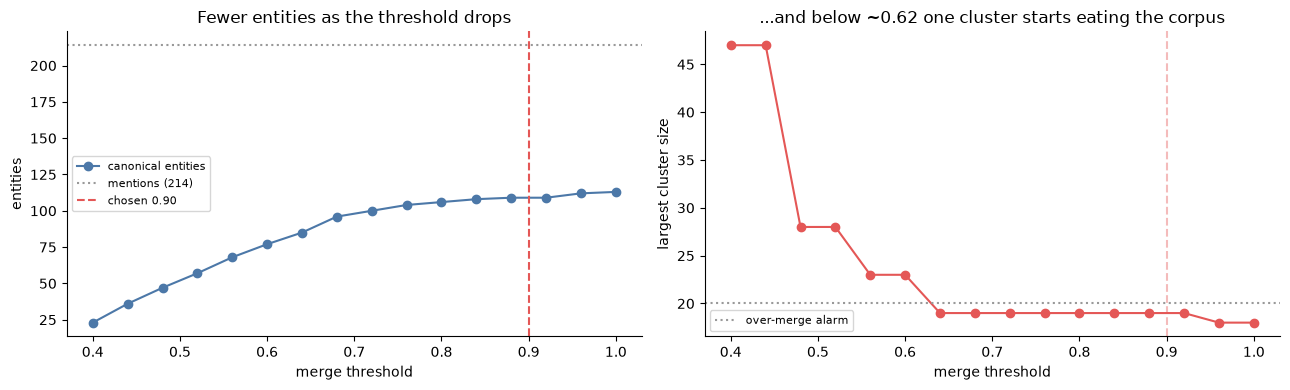

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
threshold,0.4,0.44,0.48,0.52,0.56,0.6,0.64,0.68,0.72,0.76,0.8,0.84,0.88,0.92,0.96,1.0
entities,23.0,36.00,47.00,57.00,68.00,77.0,85.00,96.00,100.00,104.00,106.0,108.00,109.00,109.00,112.00,113.0
max_cluster,47.0,47.00,28.00,28.00,23.00,23.0,19.00,19.00,19.00,19.00,19.0,19.00,19.00,19.00,18.00,18.0
singletons,8.0,18.00,26.00,33.00,39.00,47.0,52.00,61.00,66.00,71.00,73.0,76.00,77.00,77.00,79.00,80.0


In [32]:
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.arange(0.40, 1.001, 0.04)
sweep = []
for t in thresholds:
    r = resolver.resolve(mentions, threshold=float(t))
    sizes = [len(e.mentions) for e in r.entities.values()]
    sweep.append({"threshold": round(float(t), 2), "entities": len(r.entities),
                  "max_cluster": max(sizes), "singletons": sum(1 for s in sizes if s == 1)})
sweep_df = pd.DataFrame(sweep)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sweep_df.threshold, sweep_df.entities, marker="o", color="#4C78A8", label="canonical entities")
axes[0].axhline(len(mentions), ls=":", c="#999", label=f"mentions ({len(mentions)})")
axes[0].axvline(0.90, ls="--", c="#E45756", label="chosen 0.90")
axes[0].set_xlabel("merge threshold"); axes[0].set_ylabel("entities"); axes[0].legend(fontsize=8)
axes[0].set_title("Fewer entities as the threshold drops")

axes[1].plot(sweep_df.threshold, sweep_df.max_cluster, marker="o", color="#E45756")
axes[1].axvline(0.90, ls="--", c="#E45756", alpha=0.4)
axes[1].axhline(20, ls=":", c="#999", label="over-merge alarm")
axes[1].set_xlabel("merge threshold"); axes[1].set_ylabel("largest cluster size"); axes[1].legend(fontsize=8)
axes[1].set_title("...and below ~0.62 one cluster starts eating the corpus")
for ax in axes: ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

display(sweep_df.T)

The right panel is the one to read, and the first thing it says is that **nothing goes wrong anywhere near
the operating point.** From 1.00 down to 0.64 the largest cluster sits at 18–19 mentions and never touches
the alarm line at 20. Over the range anyone would actually tune in, the guard does not fire and entity count
falls smoothly from 113 to 85. There is no runaway to be seen and the "you must not lower the threshold"
warning has no support in that range.

Push past it and the failure appears, sharply. Around 0.60 the largest cluster jumps past the alarm, and by
0.40 it is 47 mentions and the corpus has collapsed from 113 entities to 23. That is the shape worth knowing:
connected-components over-merge is not a gradual degradation you can trade off against recall, it is flat and
then a cliff, because each threshold step admits an edge that fuses two whole components rather than adding
one mention.

The 19-mention cluster at the operating point is also, for the record, *correct* — it is Northwind under all
four of its spellings, which the next cell prints. A max-cluster alarm is a smoke detector, not a metric.

In [33]:
oversized = resolution.oversized(limit=15)
if oversized:
    for ent in oversized:
        print(f"  {ent.canonical!r} ({ent.type}) — {len(ent.mentions)} mentions")
        print(f"     aliases: {ent.aliases}")
else:
    print(f"no cluster above 15 mentions at threshold {resolution.threshold}")

print("\nlargest clusters:")
for e in sorted(resolution.entities.values(), key=lambda e: -len(e.mentions))[:10]:
    print(f"  {len(e.mentions):3}x  {e.type:18} {e.canonical:36} aliases={e.aliases}")

  'Northwind Logistics Inc' (company) — 19 mentions
     aliases: ['NWL', 'Northwind', 'Northwind Logistics', 'Northwind Logistics Inc.']

largest clusters:
   19x  company            Northwind Logistics Inc              aliases=['NWL', 'Northwind', 'Northwind Logistics', 'Northwind Logistics Inc.']
   11x  company            Halcyon Semiconductor Corporation    aliases=['Halcyon', 'Halcyon Semiconductor']
    8x  commodity          diesel                               aliases=['Diesel']
    7x  financial_metric   revenue                              aliases=[]
    6x  person             Priya Raman                          aliases=[]
    6x  person             Marcus Webb                          aliases=[]
    6x  geography          PHOENIX                              aliases=['Phoenix']
    5x  company            Cascade Freight Systems              aliases=['Cascade']
    5x  sector             freight                              aliases=['Freight']
    4x  regulator          Sur

### Measuring it: B-cubed, and the blocking ceiling

The corpus ships a gold alias table, so resolution can be scored rather than eyeballed.

**B-cubed, not pairwise F1.** Pairwise scores are dominated by whichever cluster is largest, so a single
over-merge of the two most common entities can look like a good result. B-cubed averages per *mention*, which
is what you actually care about.

In [34]:
gold = {}
for canonical, variants in ALIAS_GROUPS.items():
    variant_set = {v.strip() for v in variants}
    for m in mentions:
        if m.text.strip() in variant_set:
            gold[m.mention_id] = canonical
print(f"gold labels: {len(gold)} of {len(mentions)} mentions ({len(gold)/len(mentions):.0%}) "
      f"across {len(set(gold.values()))} entities")
print(f"the other {len(mentions)-len(gold)} mentions are unlabelled and invisible to the metric below\n")

ablations = [
    ("normalize + string similarity",   dict(use_embeddings=False), False),
    ("  + corpus alias mining",         dict(use_embeddings=False), True),
    ("  + embeddings (no aliases)",     dict(),                     False),
    ("  + both",                        dict(),                     True),
]
rows = []
for label, kw, learn in ablations:
    r = EntityResolver(threshold=0.90, **kw)
    if learn:
        r.learn_aliases(d["text"] for d in DOCUMENTS)
    res = r.resolve(mentions)
    pred = {m: res.mention_to_canon[m] for m in gold if m in res.mention_to_canon}
    b = kgx.bcubed(pred, gold)
    blk = r.blocking_report(mentions, gold)
    rows.append({"configuration": label, "entities": res.stats["canonical_entities"],
                 "B3 precision": b["precision"], "B3 recall": b["recall"], "B3 F1": b["f1"],
                 "blocking recall": blk["pair_completeness"]})
display(pd.DataFrame(rows).set_index("configuration"))

gold labels: 77 of 214 mentions (36%) across 13 entities
the other 137 mentions are unlabelled and invisible to the metric below



,entities,B3 precision,B3 recall,B3 F1,blocking recall
configuration,,,,,
normalize + string similarity,113,1.0,0.7378,0.8491,0.7404
+ corpus alias mining,112,1.0,0.8035,0.8910,0.8732
+ embeddings (no aliases),109,1.0,0.8972,0.9458,0.8142
+ both,109,1.0,0.8972,0.9458,0.8791


Read the n before the numbers: 10 documents, 13 gold entities, 77 labelled mentions. A 0.05 gap in that table
is a handful of mentions and is not a ranking.

**Precision stays at 1.000 throughout** — on the labelled subset. That is a real result and a narrower one
than it looks. Gold labels exist only for mentions whose surface string appears in `ALIAS_GROUPS`, which is
77 of 214; B-cubed is computed over those 77. If the resolver merged a gold mention with one of the other 137
the metric would not see it. So the supportable claim is "no two of the labelled mentions were wrongly
merged", not "nothing wrong is ever merged". All the movement is in recall, which is the usual shape:
over-merging is catastrophic and easy to avoid, under-merging is quiet and endemic.

**Alias mining and embeddings turn out to be substitutes here, not complements.** That is not what the
blocking-recall column suggests, and the two columns have to be read together. Alias mining lifts blocking
recall from 0.740 to 0.873 on its own and adds another 0.065 on top of embeddings — but the end-to-end row is
identical with and without it: same 109 entities, same B-cubed precision, recall and F1 to four decimals.
Every extra candidate pair it proposed, the clusterer then declined to use.

That is worth stating plainly rather than smoothing over, because the intuition behind the design is still
right and the corpus is just too easy to show it: embeddings raise the *score* of pairs that are already
candidates, alias mining *creates* candidates that neither string nor vector similarity would propose, and
those are genuinely different levers. On ten documents the pairs alias mining adds are pairs the embeddings
had already caught. On a corpus where a ticker appears with no spelled-out antecedent nearby, they would not
be. Blocking recall remains the hard ceiling — it just is not the binding constraint at this scale, and the
lesson is to measure both stages rather than assume the intermediate metric converts.

In [35]:
review = resolution.review_band(low=0.78, high=0.90)
print(f"{len(review)} pairs in the review band [0.78, 0.90) — too close to call\n")
band = pd.DataFrame([p.as_record() for p in review])
if len(band):
    band["a_text"] = band.a.map({m.mention_id: m.text for m in mentions})
    band["b_text"] = band.b.map({m.mention_id: m.text for m in mentions})
    display(band[["a_text", "b_text", "type", "fuzz", "embed", "context", "score", "reason"]].head(10))

39 pairs in the review band [0.78, 0.90) — too close to call



,a_text,b_text,type,fuzz,embed,context,score,reason
0,Northwind Logistics Inc.,Northwind,company,0.95,0.528,0.373,0.88,org name is a token prefix (unconfirmed)
1,Northwind Logistics,Northwind,company,0.95,0.527,0.435,0.88,org name is a token prefix (unconfirmed)
2,Northwind Logistics,Northwind,company,0.95,0.417,0.436,0.88,org name is a token prefix (unconfirmed)
3,Northwind Logistics Inc.,Northwind,company,0.95,0.600,0.374,0.88,org name is a token prefix (unconfirmed)
4,Northwind,Northwind Logistics,company,0.95,0.530,0.439,0.88,org name is a token prefix (unconfirmed)
5,Northwind,Northwind Logistics Inc.,company,0.95,0.483,0.377,0.88,org name is a token prefix (unconfirmed)
6,Northwind,Northwind Logistics Inc.,company,0.95,0.456,0.418,0.88,org name is a token prefix (unconfirmed)
7,Northwind,Northwind Logistics Inc.,company,0.95,0.521,0.477,0.88,org name is a token prefix (unconfirmed)
8,Northwind,Northwind Logistics,company,0.95,0.554,0.459,0.88,org name is a token prefix (unconfirmed)
9,Northwind,Northwind Logistics,company,0.95,0.599,0.484,0.88,org name is a token prefix (unconfirmed)


This band is the review queue, and it is the natural place for an LLM adjudicator — a few dozen pairs, each
needing a judgement call that string and vector similarity have both declined to make. Deciding whether two
`financial_metric` spans called "revenue" from different filings are the same node is a semantic question,
not a lexical one.

Emitting these as candidates beats guessing in either direction. **Ambiguity is data.** Note also that they
would be adjudicated *once* and cached — this is not a per-document LLM cost.

### Stage 5 — canonicalize, and build the graph

Rewrite every edge endpoint from a document-local mention id to a canonical entity id, then collapse the
duplicates that fall out. Each surviving edge keeps the **evidence** that produced it: document ids,
character offsets, per-occurrence confidences, and a text snippet.

That is not bookkeeping. A graph built by a 194M-parameter model *will* contain wrong edges, and an edge you
cannot trace to a sentence cannot be audited, corrected, or trusted.

In [36]:
kg = kgx.build_graph(doc_graphs, resolution, kgx.BUSINESS_NEWS)

print(kg.summary())
print()
funnel = pd.DataFrame([
    {"stage": "raw mentions",         "count": kg.stats["raw_mentions"]},
    {"stage": "canonical entities",   "count": kg.stats["canonical_entities"]},
    {"stage": "raw edges",            "count": kg.stats["raw_edges"]},
    {"stage": "canonical edges",      "count": kg.stats["canonical_edges"]},
]).set_index("stage")
display(funnel)
print(f"edge reduction: {kg.stats['edge_reduction']:.1%} — that fraction of 'edges' was the same fact restated")
print(f"dropped as self-loops: {kg.stats['dropped_self_loops']}   "
      f"dropped as unresolved: {kg.stats['dropped_unresolved']}")

KnowledgeGraph: 109 entities, 68 edges
  node labels: {'geography': 23, 'financial_metric': 19, 'product': 10, 'business_segment': 9, 'company': 7, 'security': 7, 'business_event': 7, 'person': 7, 'sector': 6, 'risk_factor': 6, 'regulator': 5, 'commodity': 3}
  edge types:  {'operates_in': 16, 'reports_metric': 13, 'officer_of': 7, 'produces': 7, 'partners_with': 6, 'competes_with': 4, 'participant_in': 4, 'subsidiary_of': 4, 'faces_risk': 4, 'acquires': 2, 'impacts': 1}



,count
stage,
raw mentions,214
canonical entities,109
raw edges,170
canonical edges,68


edge reduction: 60.0% — that fraction of 'edges' was the same fact restated
dropped as self-loops: 0   dropped as unresolved: 0


In [37]:
from kgx.evaluate import graph_triples

# Same gold facts, same policy as §5 -- now against canonical names instead of
# surface strings, which is the only thing that changed.
resolved_score = score_triples(graph_triples(kg), GOLD_DOC_FACTS, policy=POLICY, aliases=ALIAS_GROUPS)
print(f"                 triples  precision  recall     F1")
print(f"surface (§5)     {len(surface_triples):7}     {raw_score.precision:.3f}  {raw_score.recall:.3f}  {raw_score.f1:.3f}")
print(f"resolved graph   {len(kg.edges):7}     {resolved_score.precision:.3f}  {resolved_score.recall:.3f}  {resolved_score.f1:.3f}")
print(f"\nmissed gold facts ({len(resolved_score.missed)}):")
for h, r, t in resolved_score.missed[:12]:
    print(f"  {h} —{r}→ {t}")

                 triples  precision  recall     F1
surface (§5)          95     0.200  0.404  0.268
resolved graph        68     0.279  0.404  0.330

missed gold facts (28):
  Northwind Logistics Inc. —has_stake_in→ Meridian Rail Group
  Northwind Logistics Inc. —supplies→ Halcyon Semiconductor Corporation
  Torrent Microsystems —supplies→ Northwind Logistics Inc.
  Vantage Energy Partners —supplies→ Northwind Logistics Inc.
  Vantage Energy Partners —supplies→ Halcyon Semiconductor Corporation
  Northwind Logistics Inc. —operates_in→ Seattle
  Halcyon Semiconductor Corporation —operates_in→ Dresden
  Halcyon Semiconductor Corporation —operates_in→ Penang
  Northwind Logistics Inc. —reports_metric→ FY2025 revenue of $2.41 billion
  Northwind Logistics Inc. —reports_metric→ FY2025 adjusted operating margin of 8.7%
  Northwind Logistics Inc. —reports_metric→ FY2025 adjusted EPS of $3.12
  Cascade Freight Systems —reports_metric→ FY2025 revenue of $612 million


**Resolution bought precision, not recall.** Collapsing 95 surface triples into 68 canonical edges moved
precision from 0.200 to 0.279 and left recall at 0.404 — the same gold facts, matched the same number of
times. That is the arithmetic of merging duplicates: the denominator shrinks and the numerator does not move.
Worth knowing before you tune the resolver hoping to recover facts. Under-merging costs you a *messier*
graph; on this corpus it does not cost you a fact.

For calibration, that 0.330 F1 is the same number notebook 03 reports for GLiNER2.5 on this corpus under the
same matching policy. Claude Haiku 4.5 scores 0.365 there — three and a half points of F1, which on 47 gold
facts is inside the noise, and it is the wrong column to read. Recall is 0.404 against Claude's 0.617: 19
gold facts matched against 29. That gap is ten facts and notebook 03 says plainly it is larger than the
error bars. The encoder is not competitive with the LLM on how much it finds; what it is competitive on is
what a found fact costs.

**The missed list is a reading list.** Four of the 28 misses are `supplies` facts, and `supplies` turns out to
have zero edges anywhere in this graph — §8 picks that up. Several more are `reports_metric` against gold
tails like *"FY2025 revenue of $2.41 billion"*, where the extractor found the metric name and dropped the
period and the figure. That is a span-boundary disagreement rather than a missed fact, and a stated matching
policy makes it visible instead of silently forgiving it.

In [38]:
print("Edges corroborated by more than one document — the ones to trust first:\n")
display(kg.frame(min_support=2).query("docs > 1").head(15))

Edges corroborated by more than one document — the ones to trust first:



,head,head_type,relation,tail,tail_type,confidence,support,docs,derived
2,Northwind Logistics Inc,company,reports_metric,revenue,financial_metric,0.870,7,2,False
6,Northwind Logistics Inc,company,acquires,Cascade Freight Systems,company,0.943,5,3,False
7,Priya Raman,person,officer_of,Northwind Logistics Inc,company,0.927,5,4,False
8,Marcus Webb,person,officer_of,Northwind Logistics Inc,company,0.973,4,4,False
14,Ana Duarte,person,officer_of,Halcyon Semiconductor Corporation,company,0.948,3,3,False
15,Cascade Freight Systems,company,subsidiary_of,Northwind Logistics Inc,company,0.913,3,2,False
17,Northwind Logistics Inc,company,partners_with,Meridian Rail Group,company,0.782,3,2,False


`support` (how many occurrences asserted this edge) and `docs` (across how many documents) are separate
signals, and `docs > 1` is much the stronger of the two. Ten occurrences inside one press release is one
source repeating itself; two occurrences across two independent documents is corroboration.

In [39]:
# Every claim traces back to text in one hop.
for head, rel, tail in [("Northwind Logistics Inc.", "acquires", "Cascade Freight Systems"),
                        ("Halcyon Semiconductor Corporation", "competes_with", "Torrent Microsystems")]:
    ev = kg.evidence_for(head, rel, tail)
    print(f"── {head} —{rel}→ {tail}  ({len(ev)} occurrences)")
    for e in ev[:3]:
        print(f"     [{e.doc_id} @{e.head_span[0]}] {e.confidence:.2f}  …{e.snippet}…")
    print()

── Northwind Logistics Inc. —acquires→ Cascade Freight Systems  (5 occurrences)
     [d01 @10] 0.94  …SEATTLE — Northwind Logistics Inc. (NASDAQ: NWL) today announced that it has entered into a definitive agreeme……
     [d01 @10] 0.93  …SEATTLE — Northwind Logistics Inc. (NASDAQ: NWL) today announced that it has entered into a definitive agreeme……
     [d07 @27] 0.56  …01. On May 4, 2026, Northwind Logistics Inc. (the "Company") received a subpoena from the Securities and Excha……

── Halcyon Semiconductor Corporation —competes_with→ Torrent Microsystems  (2 occurrences)
     [d10 @1159] 0.97  …e aggressively with Torrent Microsystems in radar front-ends, and we held share in the quarter despite their p……
     [d10 @53] 0.95  …er: Good afternoon. Halcyon delivered second quarter revenue of $1.29 billion, up 8.1% year over year, with no……



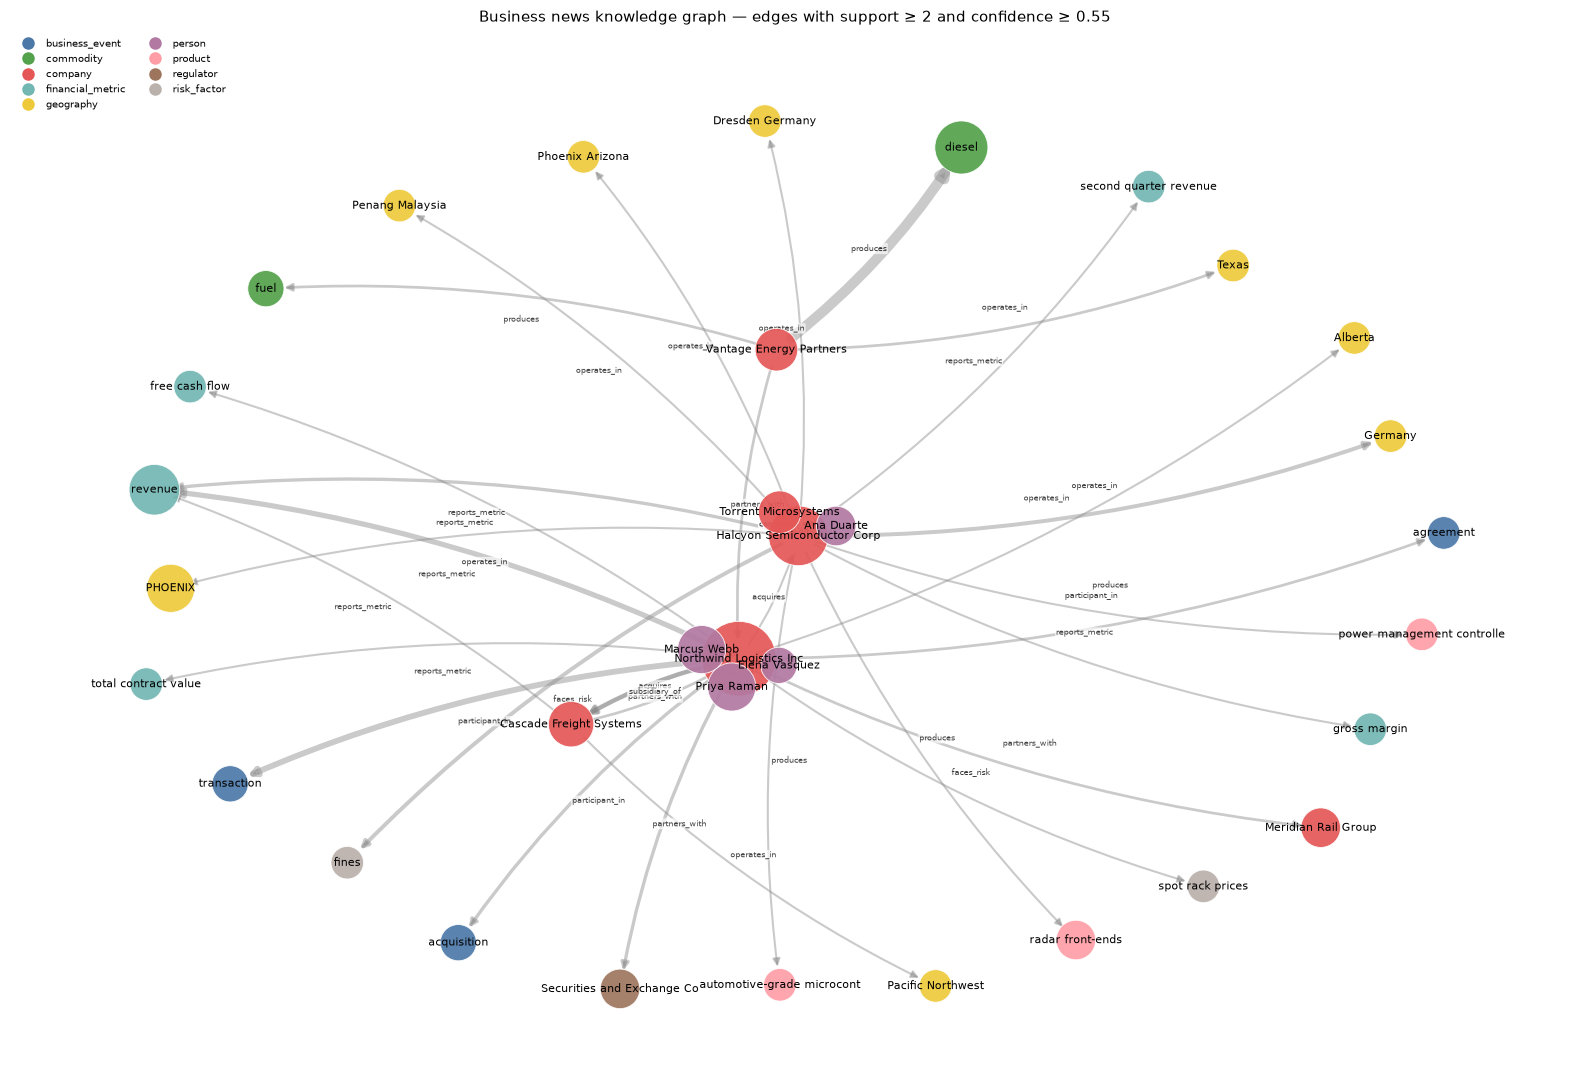

In [40]:
fig, ax = plt.subplots(figsize=(16, 11))
kgx.draw(kg, min_confidence=0.55, min_support=2, ax=ax,
         title="Business news knowledge graph — edges with support ≥ 2 and confidence ≥ 0.55")
plt.tight_layout(); plt.show()

## 8. Querying the graph

The questions worth asking are the multi-hop ones — the ones a vector store answers badly because the answer is a *path*, not a passage.

In [41]:
def show(title, rows):
    print(f"── {title}")
    print("   " + ("\n   ".join(rows) if rows else "(nothing found)") + "\n")

nw = kg.find("Northwind Logistics Inc.", "company")[0]
show(f"Everything about {nw.canonical} (aliases: {', '.join(nw.aliases)})",
     [f"{e.type:16} → {kg.name(e.tail):34} conf={e.confidence:.2f} support={e.support}"
      for e in sorted(kg.out_edges(nw.canon_id), key=lambda e: -e.confidence)])

show("Who is an officer of what",
     [f"{kg.name(e.head):26} officer_of  {kg.name(e.tail)}" for e in kg.edges if e.type == "officer_of"])

show("Supply-chain exposure — who supplies whom",
     [f"{kg.name(e.head):26} supplies    {kg.name(e.tail)}" for e in kg.edges if e.type == "supplies"])

# Two hops: which companies are exposed to a company under regulatory scrutiny?
scrutinised = {e.head for e in kg.edges if e.type in ("subject_to", "party_to")}
show("Two hops: companies connected to an entity under regulatory scrutiny",
     [f"{kg.name(s):30} ←{e.type}— {kg.name(e.head)}"
      for s in scrutinised for e in kg.in_edges(s) if e.type in ("supplies", "partners_with", "subsidiary_of")])

── Everything about Northwind Logistics Inc (aliases: NWL, Northwind, Northwind Logistics, Northwind Logistics Inc.)
   acquires         → Cascade Freight Systems            conf=0.94 support=5
   faces_risk       → supply disruptions                 conf=0.92 support=1
   partners_with    → Securities and Exchange Commission conf=0.90 support=4
   subsidiary_of    → Halcyon Semiconductor Corporation  conf=0.87 support=1
   reports_metric   → revenue                            conf=0.87 support=7
   participant_in   → transaction                        conf=0.86 support=8
   acquires         → Halcyon Semiconductor Corporation  conf=0.82 support=2
   partners_with    → Meridian Rail Group                conf=0.78 support=3
   reports_metric   → total contract value               conf=0.77 support=2
   partners_with    → Halcyon Semiconductor Corporation  conf=0.75 support=1
   participant_in   → acquisition                        conf=0.74 support=4
   faces_risk       → spot rack pric

Two of those four came back empty, and the flagship one is among them, so read them before moving on.

**`supplies` has no edges at all.** Not a low-confidence edge that got filtered — the relation never fired
anywhere in the corpus. Check that against the modality traps printed in §5: the `d03` entry says in as many
words that *"the supplies(Torrent, Northwind) clause IS asserted"*, alongside a hypothetical about tariffs in
the same sentence. So a gold relation that the corpus was written to contain was missed, and the miss shows
up here as an empty result rather than as a wrong answer.

**The two-hop query then has nothing to traverse.** It looks for a supply, partnership or ownership edge into
a company under regulatory scrutiny, and it is empty for a compounding reason: `supplies` is absent, and
`subject_to` never fired either — the SEC subpoena in `d07` came out as `partners_with` instead, which §9
takes apart. Two missing relation types, and the query that was supposed to justify the whole structure
returns nothing.

That is the honest state of this graph: the two queries that work are the ones whose relations the extractor
found, and no amount of graph machinery rescues a relation the extraction stage never emitted. It is also
exactly the signal the escalation trigger in notebook 03 keys on — a document with plenty of entities and few
edges between them.

### Filtering on modality

The qualifier pass earns its keep here. Without it, *"we may face supply disruptions if tariffs rise"*
produces a `faces_risk` edge indistinguishable from a disclosed, materialised risk.

In [42]:
hypothetical = {e.canon_id for e in kg.entities.values()
                if (e.attrs.get("modality") or {}).get("label") in {"hypothetical", "negated", "forecast"}}
risk_edges = [e for e in kg.edges if e.type in ("faces_risk", "impacts")]
grounded = [e for e in risk_edges if e.tail not in hypothetical and e.head not in hypothetical]

print(f"risk/impact edges total:                {len(risk_edges)}")
print(f"after dropping hypothetical endpoints:  {len(grounded)}\n")
for e in risk_edges:
    flag = "  ← FILTERED (hypothetical/negated)" if e not in grounded else ""
    print(f"  {kg.name(e.head):32} -{e.type:11}-> {kg.name(e.tail):26} {e.confidence:.2f}{flag}")

risk/impact edges total:                5
after dropping hypothetical endpoints:  3

  Northwind Logistics Inc          -faces_risk -> supply disruptions         0.92
  Torrent Microsystems             -faces_risk -> price                      0.39
  Halcyon Semiconductor Corporation -faces_risk -> fines                      0.96
  Northwind Logistics Inc          -faces_risk -> spot rack prices           0.74  ← FILTERED (hypothetical/negated)
  Arizona summer peak pricing      -impacts    -> PHOENIX                    0.38  ← FILTERED (hypothetical/negated)


## 9. What this graph gets wrong

It would be dishonest to render a picture and move on. A 194M-parameter model extracting fifteen relation
types zero-shot makes mistakes, and the mistakes have structure worth understanding.

In [43]:
suspect = [
    ("Northwind Logistics Inc.", "subsidiary_of", "Halcyon Semiconductor Corporation"),
    ("Northwind Logistics Inc.", "partners_with", "Securities and Exchange Commission"),
    ("Northwind Logistics Inc.", "partners_with", "Cascade Freight Systems"),
]
for head, rel, tail in suspect:
    ev = kg.evidence_for(head, rel, tail)
    if not ev:
        continue
    print(f"── {head} —{rel}→ {tail}   conf={max(e.confidence for e in ev):.2f}, support={len(ev)}")
    print(f"     …{ev[0].snippet}…\n")

── Northwind Logistics Inc. —subsidiary_of→ Halcyon Semiconductor Corporation   conf=0.87, support=1
     …er: Good afternoon. Halcyon delivered second quarter revenue of $1.29 billion, up 8.1% year over year, with no……

── Northwind Logistics Inc. —partners_with→ Securities and Exchange Commission   conf=0.90, support=4
     …01. On May 4, 2026, Northwind Logistics Inc. (the "Company") received a subpoena from the Securities and Excha……

── Northwind Logistics Inc. —partners_with→ Cascade Freight Systems   conf=0.58, support=6
     …ted average price. Cascade Freight Systems operates 41 cross-dock terminals across the Pacific Northwest and r……



Three distinct failure modes, and only one of them is fixable by tuning:

| edge | what happened | fix |
|---|---|---|
| `Northwind subsidiary_of Halcyon` | co-occurrence in a supply-chain sentence read as ownership | confidence + support filtering; the edge has support 1 |
| `Northwind partners_with SEC` | receiving a subpoena is a *relationship*, and the ontology's nearest label is `partners_with` | **ontology bug** — `subject_to` exists but the model preferred the wrong label; sharpen the descriptions |
| `Northwind partners_with Cascade` | true-ish but wrong relation — Northwind is *acquiring* Cascade | overlapping relation semantics; `acquires` also fires, at higher confidence |

The middle row is the important one. It is not a model failure — it is a **specification failure**, and the
kind that will dominate your error budget in practice. `partners_with` and `subject_to` both plausibly
describe "company and regulator in a sentence together", and the schema never said which wins. Relation
descriptions are annotation guidelines: write them with the negative case (*"a stated partnership or joint
venture — **not** an investigation or enforcement action"*) and this class of error largely goes away.

The `fix` column for the first row generalises badly, and the numbers above say so. Only the `subsidiary_of`
edge is thin: support 1, one document. The SEC edge is confidence 0.90 at support 4, and the Cascade edge is
support 6 — among the highest-support edges anywhere in this graph. **A wrong edge asserted four times is
still asserted four times**, and support counts assertions, not independent witnesses.

`docs > 1` is the filter that would have caught the SEC edge, because all four of its occurrences are in
`d07`. `support ≥ 2` catches none of it. The export below uses `min_support=2`, so the acknowledged-wrong
`partners_with SEC` edge ships in `business_news.cypher` and is what notebook 02 loads into Neo4j. That is
deliberate: it is a realistic artifact, and a retrieval notebook that never surfaces a bad edge is not
teaching anything about retrieval over extracted graphs. It is stated here so it is not a surprise there.

### Export to Neo4j

`MERGE` on `canon_id` throughout, so re-running after a re-extraction updates in place instead of duplicating. Evidence rides along on the relationship.

In [44]:
cypher = kgx.to_cypher(kg, min_confidence=0.6, min_support=2)
out = ROOT / "output" / "business_news.cypher"
out.parent.mkdir(exist_ok=True)
out.write_text(cypher)
print(f"{len(cypher.splitlines())} statements -> {out.relative_to(ROOT)}\n")

lines = cypher.splitlines()
first_match = next(i for i, l in enumerate(lines) if l.startswith("MATCH"))
print("\n".join(lines[:4]))
print("   ...")
print("\n".join(lines[first_match:first_match + 3]))

226 statements -> output/business_news.cypher

// Generated by kgx.graph.to_cypher
CREATE CONSTRAINT businessevent_id IF NOT EXISTS FOR (n:BusinessEvent) REQUIRE n.canon_id IS UNIQUE;
CREATE CONSTRAINT businesssegment_id IF NOT EXISTS FOR (n:BusinessSegment) REQUIRE n.canon_id IS UNIQUE;
CREATE CONSTRAINT commodity_id IF NOT EXISTS FOR (n:Commodity) REQUIRE n.canon_id IS UNIQUE;
   ...
MATCH (a {canon_id: "company:northwind-logistics-inc"}), (b {canon_id: "company:cascade-freight-systems"})
MERGE (a)-[r:ACQUIRES]->(b)
SET r.confidence = 0.9434, r.support = 5, r.docs = ["d01", "d04", "d07"], r.evidence = ["SEATTLE \u2014 Northwind Logistics Inc. (NASDAQ: NWL) today announced that it has entered into a definitive agreeme\u2026", "SEATTLE \u2014 Northwind Logistics Inc. (NASDAQ: NWL) today announced that it has entered into a definitive agreeme\u2026", "01. On May 4, 2026, Northwind Logistics Inc. (the \"Company\") received a subpoena from the Securities and Excha\u2026"];


In [45]:
# Interactive version: hover a node for aliases, an edge for its evidence snippets.
path = kgx.to_pyvis(kg, ROOT / "output" / "business_news.html", min_confidence=0.55, min_support=2)
print(f"wrote {path.relative_to(ROOT)}  ({path.stat().st_size//1024} KB) — open it in a browser")

wrote output/business_news.html  (719 KB) — open it in a browser


---

# Use case B — Agent memory

Same model, same joint decoding, genuinely different problem.

Five conversation sessions between a coding assistant and one user, spread over four months. 80 turns.
The user states preferences, changes some of them, mentions colleagues by first name, refers to projects as
"the migration", and says almost everything about themselves as **"I"**.

Three things break here that did not break on press releases:

1. **Coreference.** Half the facts are stated about `I`, `he`, or `the migration`. GLiNER2.5 has no
   coreference model — none — so this has to be handled before extraction or not at all.
2. **Input length.** Feed a whole transcript in one call and relation extraction quietly gives up a large
   fraction of what it would find on the same text in pieces. §11 measures how much, across all five
   sessions.
3. **Time.** The user preferred npm in February and pnpm in May. Both statements are true; only one is
   *current*. A graph that holds both is worse than useless — the assistant picks one at random.

In [46]:
from kgx.data.conversations import SESSIONS, CONTRADICTIONS, GOLD_MEMORY_FACTS

print(f"{len(SESSIONS)} sessions, {sum(len(s['turns']) for s in SESSIONS)} turns, "
      f"{sum(len(t['text'].split()) for s in SESSIONS for t in s['turns'])} words\n")
for s in SESSIONS:
    print(f"  {s['session_id']}  {s['timestamp'][:10]}  {len(s['turns']):2} turns  {s['title']}")

print("\nplanted contradictions:")
for c in CONTRADICTIONS:
    print(f"  {c['subject']} {c['relation']}: {c['old']} ({c['old_session']}) -> {c['new']} ({c['new_session']})")

print("\n--- session 1, first turns ---")
for t in SESSIONS[0]["turns"][:4]:
    print(f"  {t['speaker']:9}: {t['text'][:130]}")

5 sessions, 80 turns, 2031 words

  s1  2026-02-10  16 turns  Order graph kickoff
  s2  2026-03-04  16 turns  Migration tooling and telemetry detour
  s3  2026-04-15  16 turns  Q2 review prep and the two blockers
  s4  2026-05-20  16 turns  Tooling switch and the workshop
  s5  2026-06-18  16 turns  Standardizing on Go

planted contradictions:
  Priya Raman prefers: npm (s1) -> pnpm (s4)
  Priya Raman prefers: Python (s2) -> Go (s5)

--- session 1, first turns ---
  user     : morning. quick context since this is our first time working together — I'm Priya Raman, I lead the Platform Engineering team at No
  assistant: Morning Priya. Happy to be the sanity check. What's the project, and what's the shape of the thing you're moving?
  user     : we're calling it the Order Graph Migration. the order service lives on Postgres today — like nine years of accreted schema — and w
  assistant: That's a reasonable motivation — if the hot queries are variable-depth traversals, joins will keep puni

## 10. The coreference problem

Extract a raw turn and watch what the model can and cannot attribute.

In [47]:
raw_turn = SESSIONS[0]["turns"][0]["text"]
print(f"RAW:\n  {raw_turn}\n")

g_raw = extractor.extract(raw_turn, kgx.AGENT_MEMORY, "raw")
print("extracted from the raw turn:")
for e in g_raw.edges:
    print(f"  {g_raw.mention(e.head).text!r:22} -{e.type}({e.confidence:.2f})-> {g_raw.mention(e.tail).text!r}")
if not g_raw.edges:
    print("  (nothing — the subject of every fact in this turn is 'I')")

RAW:
  morning. quick context since this is our first time working together — I'm Priya Raman, I lead the Platform Engineering team at Northwind Logistics. freight brokerage, mostly EU lanes, lots of very old order data. I'm kicking off a project this week and want a sanity check before I write it up.



extracted from the raw turn:


  'Priya Raman'          -avoids(0.50)-> 'order data'
  'Priya Raman'          -has_skill(0.63)-> 'Platform Engineering'
  'project'              -part_of(0.81)-> 'Northwind Logistics'
  'Priya Raman'          -pursues(0.83)-> 'sanity check'
  'Priya Raman'          -works_at(0.94)-> 'Northwind Logistics'
  'Priya Raman'          -works_on(0.97)-> 'project'


There is no escape hatch inside the model for this. So three deterministic layers run *before* extraction,
each inspectable and each individually ablatable:

1. **Speaker attribution + first-person substitution** — prefix each turn with the speaker's real name and
   rewrite `I` / `me` / `my` in user turns to that name. A rule, not a model.
2. **Bare first-name expansion** — `Dev` → `Dev Shah`, but only when exactly one person in the session roster
   has that given name. Two candidates means genuinely ambiguous, and it is left alone.
3. **Recency-bound third-person pronouns** — sentence-initial `he`/`she`/`they` bind to the most recently
   mentioned non-user person, within a window, only when unambiguous.

Layer 3 is crude and will sometimes be wrong. It is here because it is cheap and **auditable** — every
rewrite is logged, so its accuracy can be checked rather than assumed. The upgrade path is a real
coreference model (`fastcoref` for throughput, `maverick-coref` for accuracy — check its licence); see
`docs/LANDSCAPE.md`.

In [48]:
ROSTER = ["Priya Raman", "Dev Shah", "Marcus Webb", "Elena Vasquez", "Tomás Ferreira"]
pre = kgx.ConversationPreprocessor("Priya Raman", roster=ROSTER)

rendered = pre.render(SESSIONS[0])
print("REWRITTEN:\n")
for line in rendered.turn_texts[:5]:
    print(f"  {line[:150]}")

print("\nthe rewrite log — every substitution, auditable:")
display(rendered.rewrites_frame().head(12))

REWRITTEN:

  Priya Raman: morning. quick context since this is our first time working together — Priya Raman is Priya Raman, Priya Raman lead the Platform Engineer
  Assistant: Morning Priya Raman. Happy to be the sanity check. What's the project, and what's the shape of the thing you're moving?
  Priya Raman: we're calling it the Order Graph Migration. the order service lives on Postgres today — like nine years of accreted schema — and we want 
  Assistant: That's a reasonable motivation — if the hot queries are variable-depth traversals, joins will keep punishing you. Are you moving the whole 
  Priya Raman: read model first, definitely. writes stay on Postgres until we trust the thing. Dev Shah is doing the backend work on it — he's on Priya 

the rewrite log — every substitution, auditable:


,turn,layer,from,to,reason
0,0,first_person,I,Priya Raman,"user turn, first person"
1,0,first_person,I,Priya Raman,"user turn, first person"
2,1,first_name,Priya,Priya Raman,unique given name in roster (priya)
3,4,first_person,my,Priya Raman's,"user turn, first person"
4,5,first_name,Dev,Dev Shah,unique given name in roster (dev)
5,6,pronoun,he,Dev Shah,"sentence-initial pronoun, unique anteceden..."
6,6,pronoun,he,Dev Shah,"sentence-initial pronoun, unique anteceden..."
7,8,first_person,me,Priya Raman,"user turn, first person"
8,8,first_name,Dev,Dev Shah,unique given name in roster (dev)
9,10,first_person,I,Priya Raman,"user turn, first person"


The rewrites are deliberately literal, and the output is not always grammatical — *"Priya Raman lead the
team"*, *"Priya Raman is Priya Raman"*. That is the honest cost of a rule-based layer, and it matters less
than it looks: the extractor scores spans, not sentences, and a subject that is a name rather than a pronoun
is exactly what it needs. Fluency would be nice; attribution is the requirement.

In [49]:
# Same turn, now attributable.
g_fixed = extractor.extract(rendered.turn_texts[0], kgx.AGENT_MEMORY, "fixed")
print("after preprocessing:")
for e in sorted(g_fixed.edges, key=lambda e: -e.confidence):
    print(f"  {g_fixed.mention(e.head).text!r:22} -{e.type}({e.confidence:.2f})-> {g_fixed.mention(e.tail).text!r}")

after preprocessing:
  'Priya Raman'          -works_at(0.98)-> 'Northwind Logistics'
  'Priya Raman'          -works_at(0.97)-> 'Northwind Logistics'
  'Priya Raman'          -works_at(0.97)-> 'Northwind Logistics'
  'Priya Raman'          -works_on(0.97)-> 'project'
  'Priya Raman'          -works_on(0.97)-> 'project'
  'Priya Raman'          -works_at(0.96)-> 'Northwind Logistics'
  'Priya Raman'          -works_at(0.96)-> 'Northwind Logistics'
  'Priya Raman'          -works_on(0.96)-> 'project'
  'Priya Raman'          -pursues(0.96)-> 'sanity check'
  'Priya Raman'          -works_on(0.96)-> 'project'
  'Priya Raman'          -pursues(0.96)-> 'sanity check'
  'Priya Raman'          -works_on(0.96)-> 'project'
  'Priya Raman'          -works_at(0.95)-> 'Northwind Logistics'
  'Priya Raman'          -works_on(0.95)-> 'project'
  'Priya Raman'          -pursues(0.95)-> 'sanity check'
  'Priya Raman'          -pursues(0.95)-> 'sanity check'
  'Priya Raman'          -pursues(0.94)-> '

### Ablating the layers

Each layer is worth measuring rather than assuming. Turn them on one at a time and count what is recovered
about the user.

The unit matters more than it looks. Episodes overlap (window 4, stride 3), so every turn is extracted twice
and every repeated span counts again — and the cell above shows what that does: one turn produced roughly
thirty identical `Priya Raman -collaborates_with-> Priya Raman` self-loops, all manufactured by the very
rewrite this ablation is meant to be measuring. Counting raw edges would credit first-person substitution for
its own artefacts. So count **distinct `(head, relation, tail)` triples with self-loops excluded**, and keep
the raw count and the self-loop count beside it to show the gap.

In [50]:
LAYER_SETS = [
    ("nothing (raw turns)",         ()),
    ("speaker labels only",         ("speaker",)),
    ("+ first-person substitution", ("speaker", "first_person")),
    ("+ first-name expansion",      ("speaker", "first_person", "first_name")),
    ("+ pronoun binding (all)",     ("speaker", "first_person", "first_name", "pronoun")),
]

rows = []
for label, layers in LAYER_SETS:
    p = kgx.ConversationPreprocessor("Priya Raman", roster=ROSTER, layers=layers)
    eps = p.episodes(SESSIONS, window=4, stride=3)
    gs = extractor.extract_batch(eps, kgx.AGENT_MEMORY)
    p.clean_mentions(gs)

    raw = [(g.mention(e.head).text.casefold(), e.type, g.mention(e.tail).text.casefold())
           for g in gs for e in g.edges]
    facts = {t for t in raw if t[0] != t[2]}
    about_user = {t for t in facts if "priya" in t[0] or "priya" in t[2]}
    rows.append({"layers": label,
                 "mentions": sum(len(g.mentions) for g in gs),
                 "raw edges": len(raw),
                 "self-loops": sum(1 for t in raw if t[0] == t[2]),
                 "distinct facts": len(facts),
                 "distinct about the user": len(about_user),
                 "rewrites": sum(len(p.render(s).rewrites) for s in SESSIONS)})

ablation = pd.DataFrame(rows).set_index("layers")
display(ablation)

,mentions,raw edges,self-loops,distinct facts,distinct about the user,rewrites
layers,,,,,,
nothing (raw turns),356,160,1,82,1,0
speaker labels only,379,271,0,96,61,0
+ first-person substitution,441,595,20,109,73,36
+ first-name expansion,440,609,34,117,75,55
+ pronoun binding (all),456,650,39,123,74,62


**Speaker labelling does most of the work.** Prefixing each turn with the speaker's name takes distinct facts
about the user from 1 to 61 — over 80% of the final total — for a rule that inserts one name per turn and
performs no rewriting inside the text at all. First-person substitution adds another dozen or so on top. That
is a real contribution and it is not the order-of-magnitude jump the raw-edge column implies: raw edges go
from 271 to 595, distinct facts about the user from 61 to 73. The difference between those two ratios is
duplication the rewrite created, and the `self-loops` column tracks it going from 0 to 20 to 39 as each layer
is added. `build_graph` silently discards all 39 later.

**Pronoun binding does not pay for itself here.** It is the crudest of the three layers, it fires 7 extra
times, and it leaves the user's distinct fact count one lower than the layer below it. On this corpus it is
noise. That is the argument for keeping every layer separately switchable and for logging every rewrite:
without the ablation you would ship it, and without the log you could not tell which rewrite cost you the
fact.

None of this is a GLiNER limitation you work around. It is a **preprocessing requirement** of using any
coreference-free extractor on conversational text. Skip it and you will conclude the model is bad at
conversations, when what happened is that you asked it to resolve pronouns it has no mechanism to resolve.

## 11. The long-input collapse

The obvious way to extract a conversation is to feed the whole transcript in one call. The model's window is
4,096 words and a rendered session here is 387 to 520, so it fits several times over.

It fits, and relation extraction degrades anyway. This is the most useful practical finding in this notebook
and it is not in any documentation — the only way to find it is to measure. So measure it on all five
sessions rather than on one, because a single curve cannot tell a cliff from a bad draw.

In [51]:
LENGTHS = (40, 80, 120, 180, 250, 320, 400, 460)

rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)   # the guard fires below on purpose
    for s in SESSIONS:
        rendered = pre.render(s)
        words = rendered.text.split()
        for n in [n for n in LENGTHS if n < len(words)] + [len(words)]:
            t = time.time()
            g = extractor.extract(" ".join(words[:n]), kgx.AGENT_MEMORY, "sweep")
            rows.append({"session": s["session_id"], "words": n, "full": n == len(words),
                         "seconds": round(time.time() - t, 2), "feasible": g.feasible,
                         "mentions": len(g.mentions), "edges": len(g.edges)})

length_sweep = pd.DataFrame(rows)
session1 = pre.render(SESSIONS[0])

print("relations extracted, by prefix length:")
display(length_sweep.pivot_table(index="words", columns="session", values="edges"))
print("\nentities over the same prefixes, for comparison:")
display(length_sweep.pivot_table(index="words", columns="session", values="mentions"))
print("\nthe full-session rows — the whole transcript in one call:")
display(length_sweep[length_sweep.full].set_index("session")[["words", "mentions", "edges", "feasible"]])

relations extracted, by prefix length:


session,s1,s2,s3,s4,s5
words,,,,,
40,25.0,6.0,25.0,12.0,6.0
80,75.0,22.0,43.0,32.0,15.0
120,59.0,35.0,25.0,92.0,34.0
180,71.0,50.0,57.0,86.0,37.0
250,82.0,70.0,73.0,87.0,22.0
320,72.0,55.0,87.0,87.0,46.0
387,NaN,NaN,NaN,NaN,15.0
400,78.0,73.0,27.0,82.0,NaN
408,NaN,NaN,NaN,82.0,NaN



entities over the same prefixes, for comparison:


session,s1,s2,s3,s4,s5
words,,,,,
40,9.0,8.0,8.0,7.0,11.0
80,18.0,17.0,11.0,18.0,16.0
120,21.0,23.0,17.0,21.0,25.0
180,24.0,30.0,21.0,28.0,27.0
250,27.0,31.0,27.0,29.0,26.0
320,30.0,29.0,29.0,31.0,26.0
387,NaN,NaN,NaN,NaN,25.0
400,30.0,29.0,30.0,31.0,NaN
408,NaN,NaN,NaN,31.0,NaN



the full-session rows — the whole transcript in one call:


,words,mentions,edges,feasible
session,,,,
s1,520,29,12,True
s2,445,30,57,True
s3,469,30,24,True
s4,408,31,82,True
s5,387,25,15,True


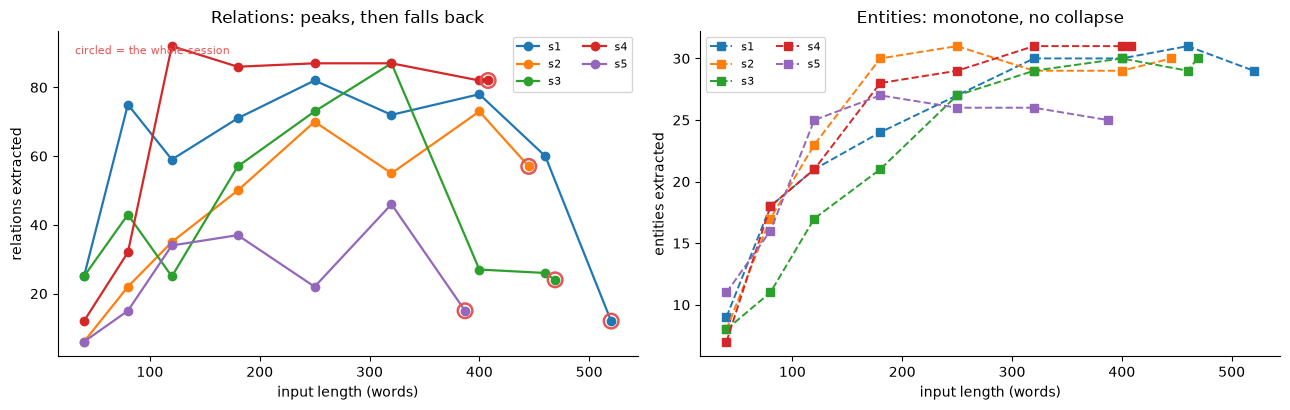

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)
for sid, grp in length_sweep.groupby("session"):
    grp = grp.sort_values("words")
    axes[0].plot(grp.words, grp.edges, marker="o", lw=1.6, label=sid)
    axes[1].plot(grp.words, grp.mentions, marker="s", ls="--", lw=1.4, label=sid)
    full = grp[grp.full]
    axes[0].scatter(full.words, full.edges, s=110, facecolors="none", edgecolors="#E45756", zorder=5, lw=1.8)

axes[0].set_ylabel("relations extracted"); axes[0].set_title("Relations: peaks, then falls back")
axes[1].set_ylabel("entities extracted");  axes[1].set_title("Entities: monotone, no collapse")
for ax in axes:
    ax.set_xlabel("input length (words)"); ax.legend(fontsize=8, ncol=2)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].annotate("circled = the whole session", xy=(0.03, 0.93), xycoords="axes fraction", fontsize=8, color="#E45756")
plt.tight_layout(); plt.show()

Entity extraction holds up. Each session's mention count climbs and then plateaus in the high twenties, and
where it does slip at full length it slips by a mention or two — nothing like what happens on the other
panel.

Relations do not. Every session peaks somewhere between 120 and 400 words and every session ends *below* its
own peak when the whole transcript goes in at once. The size of the drop is what one session could not have
told you: session 1 falls from 82 relations to 12, session 3 from 87 to 24, session 5 from 46 to 15 — and
session 4 barely moves, 92 down to 82. Three of five lose most of their relations; one loses almost nothing.

So it is a real effect and it is not a cliff at a fixed length. Note also that the per-session curves are
noisy well before the end — session 3 reads 25, 57, 73, 87, 27 across consecutive prefixes — so no single
point on any of these lines should be read as a measurement. What survives the noise is the direction: full
transcript in, fewer relations out.

**And nothing in the result says so.** `feasible` is `True` for every row above, including the 12-relation
one. No exception, no warning, no field to check. A pipeline that fed whole sessions in would return an
under-populated graph and look like it was working.

The mechanism is not established here. The obvious suspect is the count head — the model predicts, per
relation type, how many instances a window contains, and a long rambling input with sixteen relation types
competing could plausibly drive those counts down. This notebook does not inspect that head, so treat it as a
hypothesis. What *is* measured is the next cell: the collapse depends on the decoding window rather than on
the text.

In [53]:
# max_len acts as a window size, and setting it below the input length rescues the call.
full = session1.text
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    for max_len in (384, 512, 768, 1024, None):
        g = extractor.extract(full, kgx.AGENT_MEMORY, "ml", config=JointIEConfig(max_len=max_len))
        print(f"  max_len={str(max_len):5}  ->  {len(g.mentions):3} mentions, {len(g.edges):3} edges")

print("\nAnd for reference, chunked extraction over the same text:")
for chunk_size in (256, 384):
    g = extractor.extract_long(full, kgx.AGENT_MEMORY, "cl", chunk_size=chunk_size, chunk_overlap=64)
    print(f"  extract_long(chunk_size={chunk_size})  ->  {len(g.mentions):3} mentions, {len(g.edges):3} edges")

  max_len=384    ->   29 mentions,  79 edges


  max_len=512    ->   30 mentions, 102 edges


  max_len=768    ->   29 mentions,  12 edges


  max_len=1024   ->   29 mentions,  12 edges


  max_len=None   ->   29 mentions,  12 edges

And for reference, chunked extraction over the same text:


  extract_long(chunk_size=256)  ->   79 mentions, 261 edges


  extract_long(chunk_size=384)  ->   57 mentions, 188 edges


### What to do about it

Three options, in order of preference:

1. **Extract per episode.** Short overlapping windows of turns. This is also what temporal memory systems
   already do — Graphiti's "episode", mem0's message batch — so it is the right architecture independently of
   this bug. Each window keeps its own context, and the overlap means a fact spanning a turn boundary is
   still seen whole by at least one window.
2. **`extract_long(chunk_size=256..384)`** for documents that genuinely are one document.
3. **`JointIEConfig(max_len=512)`** as a blunt guard when you cannot control the input.

All three keep the input the decoder sees short. Option 3 is the interesting one, because it shows the
collapse is a property of the *decoding window* and not of the text: the same 520 words yield 79 relations at
`max_len=384` and 12 at `max_len=768` or above.

`kgx` warns when you hand it a long input with no windowing, because a silent under-extraction is the worst
failure mode there is — the pipeline keeps running and the graph is just quietly emptier:

In [54]:
import warnings as _w
with _w.catch_warnings(record=True) as caught:
    _w.simplefilter("always")
    extractor.extract(full, kgx.AGENT_MEMORY, "warn-demo")
    for c in caught:
        print(f"{c.category.__name__}: {c.message}")

In [55]:
episodes = pre.episodes(SESSIONS, window=4, stride=3)
print(f"{len(SESSIONS)} sessions -> {len(episodes)} episodes "
      f"(avg {sum(len(e['text'].split()) for e in episodes)/len(episodes):.0f} words each)\n")
print("example episode:\n")
print(episodes[1]["text"][:420], "...")

5 sessions -> 25 episodes (avg 113 words each)

example episode:

Assistant: That's a reasonable motivation — if the hot queries are variable-depth traversals, joins will keep punishing you. Are you moving the whole order service or just the read model first?
Priya Raman: read model first, definitely. writes stay on Postgres until we trust the thing. Dev Shah is doing the backend work on it — he's on Priya Raman's team, he's been at Northwind about four years.
Assistant: Got it. Do ...


In [56]:
t = time.time()
mem_graphs = extractor.extract_batch(episodes, kgx.AGENT_MEMORY)
dropped = pre.clean_mentions(mem_graphs)   # remove "Assistant"/"User" speaker-label artefacts
elapsed = time.time() - t

print(f"{len(episodes)} episodes in {elapsed:.1f}s ({elapsed/len(episodes)*1000:.0f} ms each)")
print(f"{sum(len(g.mentions) for g in mem_graphs)} mentions, {sum(len(g.edges) for g in mem_graphs)} edges")
print(f"dropped {dropped} speaker-label artefacts")
print(f"endpoint-type violations: {len([v for g in mem_graphs for v in g.validate(kgx.AGENT_MEMORY)])}")
print(f"infeasible episodes: {[g.doc_id for g in mem_graphs if not g.feasible] or 'none'}")

25 episodes in 31.2s (1247 ms each)
456 mentions, 650 edges
dropped 27 speaker-label artefacts
endpoint-type violations: 0
infeasible episodes: none


## 12. Incremental resolution

Document intelligence resolved a corpus that arrived all at once. Agent memory is the other shape: episodes
arrive one at a time, and each must be linked into what is already known *before* it is written.

`CanonicalRegistry` does two passes per episode, and both are necessary. New mentions are first matched
against the registry's existing entities; then the *unmatched remainder* is resolved among itself. Skip the
second pass and an episode mentioning "Acme" and "Acme Corp" for the first time creates two nodes — neither
had a registry entry to anchor to.

,episode,new mentions,entities before,entities after,linked to existing
0,s1:w00,20,0,13,7
1,s1:w03,19,13,26,6
2,s1:w06,20,26,37,9
3,s1:w09,26,37,49,14
4,s1:w12,28,49,59,18
5,s2:w00,22,59,70,11
6,s2:w03,21,70,83,8
7,s2:w06,12,83,90,5
8,s2:w09,14,90,99,5
9,s2:w12,22,99,110,11


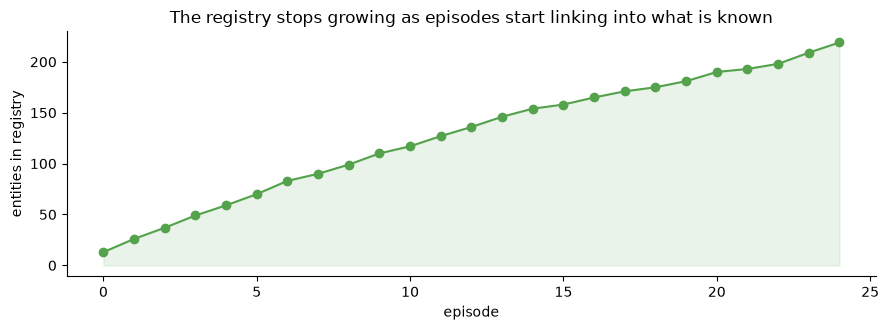

In [57]:
from kgx.coref import user_mentions, USER_CANON_ID

registry = kgx.CanonicalRegistry(kgx.EntityResolver(threshold=0.90))

growth = []
for g in mem_graphs:
    before = len(registry.entities)
    registry.add_episode(g.mentions, episode_id=g.doc_id)
    growth.append({"episode": g.doc_id, "new mentions": len(g.mentions),
                   "entities before": before, "entities after": len(registry.entities),
                   "linked to existing": len(g.mentions) - (len(registry.entities) - before)})

gdf = pd.DataFrame(growth)
display(gdf.head(10))

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(range(len(gdf)), gdf["entities after"], marker="o", color="#54A24B")
ax.fill_between(range(len(gdf)), gdf["entities after"], alpha=0.12, color="#54A24B")
ax.set_xlabel("episode"); ax.set_ylabel("entities in registry")
ax.set_title("The registry stops growing as episodes start linking into what is known")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

The curve flattening is the whole point: later episodes mostly *link* rather than *add*. A registry that
grows linearly with episodes is one that is not resolving anything, and it is the failure mode that turns an
agent's memory into a pile of near-duplicate nodes.

### Pinning the user

One entity gets special treatment. After first-person substitution, references to the user carry their name,
so they can be pinned to a stable id (`user:__self__`) rather than left to the resolver. The assistant's own
user must be exactly one node — that is not a judgement call the similarity threshold should get to make.

In [58]:
all_mentions = [m for g in mem_graphs for m in g.mentions]
pins = {mid: USER_CANON_ID for mid in user_mentions(all_mentions, "Priya Raman")}
print(f"pinned {len(pins)} mentions to {USER_CANON_ID}")

resolution_mem = registry.as_resolution()
mem_kg = kgx.build_graph(mem_graphs, resolution_mem, kgx.AGENT_MEMORY, pin=pins)
print()
print(mem_kg.summary())
print(f"\nraw edges {mem_kg.stats['raw_edges']} -> canonical {mem_kg.stats['canonical_edges']} "
      f"({mem_kg.stats['edge_reduction']:.0%} were the same fact restated)")
print(f"dropped as self-loops: {mem_kg.stats['dropped_self_loops']}  "
      f"— the 'Priya Raman is Priya Raman' artefacts from §10, discarded here")

pinned 106 mentions to user:__self__

KnowledgeGraph: 219 entities, 123 edges
  node labels: {'task': 42, 'tool': 26, 'skill': 22, 'topic': 21, 'project': 19, 'place': 16, 'event': 16, 'constraint': 13, 'artifact': 12, 'goal': 11, 'organization': 10, 'person': 10, 'user': 1}
  edge types:  {'uses_tool': 20, 'has_skill': 18, 'works_on': 9, 'prefers': 8, 'assigned_to': 8, 'attended': 8, 'works_at': 7, 'produced': 7, 'has_constraint': 6, 'blocked_by': 6, 'collaborates_with': 6, 'avoids': 5, 'part_of': 5, 'located_in': 4, 'replaces': 4, 'pursues': 2}

raw edges 650 -> canonical 123 (81% were the same fact restated)
dropped as self-loops: 39  — the 'Priya Raman is Priya Raman' artefacts from §10, discarded here


In [59]:
from kgx.evaluate import score_triples, graph_triples

# 36 gold memory facts ship with the sessions. No alias table for this corpus, so
# matching is normalised names only -- stricter than the document side.
mem_rows = []
for label, kw in [("all edges", {}), ("support >= 3", dict(min_support=3)),
                  ("conf >= 0.6, support >= 3", dict(min_confidence=0.6, min_support=3))]:
    tri = graph_triples(mem_kg, **kw)
    sc = score_triples(tri, GOLD_MEMORY_FACTS)
    mem_rows.append({"filter": label, "edges": len(tri), "precision": round(sc.precision, 3),
                     "recall": round(sc.recall, 3), "F1": round(sc.f1, 3)})
display(pd.DataFrame(mem_rows).set_index("filter"))

print("gold facts never recovered:")
for h, r, t in score_triples(graph_triples(mem_kg), GOLD_MEMORY_FACTS).missed[:12]:
    print(f"  {h} —{r}→ {t}")

,edges,precision,recall,F1
filter,,,,
all edges,123,0.130,0.444,0.201
support >= 3,64,0.219,0.389,0.280
"conf >= 0.6, support >= 3",58,0.224,0.361,0.277


gold facts never recovered:
  Priya Raman —part_of→ Platform Engineering
  Platform Engineering —part_of→ Northwind Logistics
  Dev Shah —part_of→ Platform Engineering
  Tomás Ferreira —part_of→ Platform Engineering
  Marcus Webb —works_at→ Northwind Logistics
  Priya Raman —collaborates_with→ Elena Vasquez
  Priya Raman —works_on→ Order Graph Migration
  Dev Shah —assigned_to→ Order Graph Migration
  Dev Shah —works_on→ Carrier Rate API v2
  Elena Vasquez —works_on→ Order Graph Migration
  Order Graph Migration —uses_tool→ Neo4j
  Order Graph Migration —blocked_by→ Carrier Rate API v2


Recall under 0.45 against 36 gold facts. That is a worse graph than the document side, and the gap is not
mysterious: press releases state facts in one sentence with both arguments named, and conversations do not.

Read the precision column with the same caveat as §5 — the sessions contain far more than 36 true facts, so
an unmatched edge is often true-and-unlabelled, and 123 predictions against 36 labels makes that column close
to meaningless. The *recall* number has no such excuse. More than half the facts someone hand-wrote as the
point of these five conversations are not in the graph. The filters trade recall for precision, which is what
filters do, and none of them gets recall up.

Keep this table in view for the rest of the memory sections. Everything below is built on a graph that is
missing half of what it should contain, and none of the temporal machinery can recover a fact the extractor
never emitted.

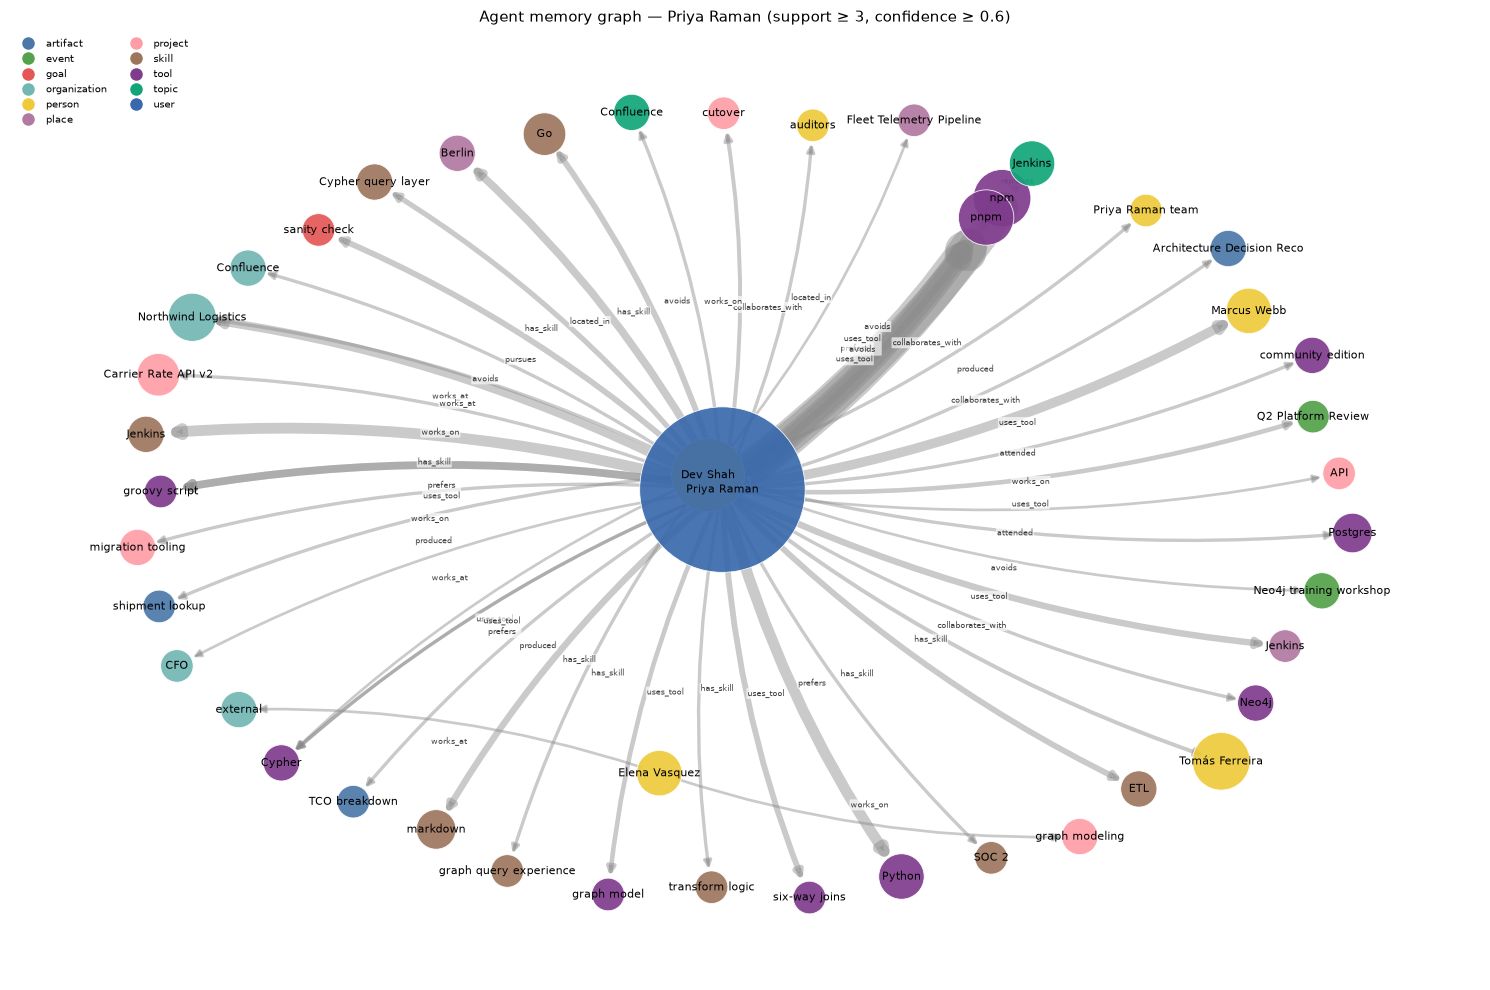

In [60]:
fig, ax = plt.subplots(figsize=(15, 10))
kgx.draw(mem_kg, min_confidence=0.6, min_support=3, ax=ax, max_nodes=45,
         title="Agent memory graph — Priya Raman (support ≥ 3, confidence ≥ 0.6)")
plt.tight_layout(); plt.show()

## 13. Time: superseding contradictions instead of accumulating them

The user was on npm in February and announced a switch to pnpm in May. Both facts are in the graph, both
carry real evidence, and only one is true *now*. A store that keeps both and cannot say which is current is
worse than useless: the assistant picks one at random on every turn.

GLiNER2.5 has no temporal model, and that is the correct division of labour — it reads one text and reports
what that text says. Handling time is a **store-layer** concern.

### The hard part is knowing what contradicts what

`prefers` is multi-valued. Preferring pnpm does not stop you preferring dark mode. It supersedes preferring
npm *only because npm and pnpm are alternatives* — and nothing in the extraction output says so.

Two approaches that do not work well enough are worth showing before the one that does.

In [61]:
from sentence_transformers import SentenceTransformer

enc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
def sim(a, b, tmpl="the software tool {}"):
    v = enc.encode([tmpl.format(a), tmpl.format(b)], normalize_embeddings=True)
    return float(v[0] @ v[1])

ALTERNATIVES = [("npm", "pnpm"), ("Python", "Go"), ("Postgres", "Neo4j"), ("Jenkins", "GitHub Actions"), ("Confluence", "Notion")]
UNRELATED = [("npm", "Berlin"), ("Python", "dark mode"), ("Go", "SOC 2"), ("npm", "Dev Shah"), ("Postgres", "markdown")]

print("genuine alternatives:")
for a, b in ALTERNATIVES: print(f"   {a:12}/{b:16} {sim(a,b):.3f}")
print("\nunrelated pairs:")
for a, b in UNRELATED: print(f"   {a:12}/{b:16} {sim(a,b):.3f}")

lo, hi = min(sim(a,b) for a,b in ALTERNATIVES), max(sim(a,b) for a,b in UNRELATED)
print(f"\nlowest genuine alternative: {lo:.3f}")
print(f"highest unrelated pair:     {hi:.3f}")
print(f"separable by a threshold?   {lo > hi}")

genuine alternatives:
   npm         /pnpm             0.697
   Python      /Go               0.633
   Postgres    /Neo4j            0.533
   Jenkins     /GitHub Actions   0.465
   Confluence  /Notion           0.809

unrelated pairs:
   npm         /Berlin           0.553
   Python      /dark mode        0.348
   Go          /SOC 2            0.622
   npm         /Dev Shah         0.624
   Postgres    /markdown         0.485

lowest genuine alternative: 0.465
highest unrelated pair:     0.624
separable by a threshold?   False


**No.** The distributions overlap: the lowest genuine alternative scores 0.465 and the highest unrelated pair
0.624, so no threshold splits them. Bare product names carry too little signal, and a MiniLM has no idea what
pnpm is. Asking the extractor to classify the tools into categories fails for the same reason — a 194M
encoder trained on synthetic data has not heard of pnpm either.

Deciding that pnpm competes with npm is a **world-knowledge question**, and neither of the small models in
this pipeline holds that knowledge.

### The information was in the text all along

The user did not silently start using pnpm. They *said so*: *"honestly I was wrong about npm — I've switched
to pnpm"*. That is a relation, and relations are what this model extracts.

So put it in the ontology. `AGENT_MEMORY` declares `replaces(tool → tool)`, and joint decoding picks it up at
the same confidence as any other edge.

In [62]:
rel = kgx.AGENT_MEMORY.relation("replaces")
print(f"{rel.name}({'|'.join(rel.head)} -> {'|'.join(rel.tail)}), acyclic={rel.acyclic}")
print(f"  \"{rel.description}\"\n")
for e in sorted([e for e in mem_kg.edges if e.type == "replaces"], key=lambda e: -e.confidence):
    print(f"  {mem_kg.name(e.head)!r} replaces {mem_kg.name(e.tail)!r}   conf={e.confidence:.2f} support={e.support}")
    print(f"      …{e.evidence[0].snippet}…")

replaces(tool|topic|place|organization -> tool|topic|place|organization), acyclic=True
  "The head has superseded or been adopted instead of the tail: a switch, a migration away from, a standardisation on something else."

  'pnpm' replaces 'npm'   conf=0.99 support=9
      …o one workspace and npm's install times were like four minutes on CI. pnpm took it to 50 secon…
  'npm' replaces 'Jenkins'   conf=0.96 support=7
      …s excited about but npm is what our CI knows and Priya Raman don't want to relearn a lockfile format this quar……
  'npm' replaces 'Jenkins'   conf=0.93 support=1
      …at this quarter. so npm, please, in anything you scaffold for Priya Raman. Assistant: Noted — npm for package……
  'Python' replaces 'ETL'   conf=0.41 support=2
      …dy read Python. so: Python for the migration tooling, that's the call. Assistant: Reasonable. Python it is for……


No world knowledge needed, and — unlike a similarity threshold — every supersession traces back to a
sentence the user actually said.

The limit is equally clear, and stated rather than hidden: this only fires when the user *announces* the
switch. A silent drift from one tool to another leaves no `replaces` edge, and those pairs land in a review
queue instead.

In [63]:
from kgx.temporal import graph_alternatives

alternatives = graph_alternatives(mem_kg, min_confidence=0.6)
memory = kgx.TemporalGraph(alternative_fn=alternatives)

by_session = {}
for g in mem_graphs:
    by_session.setdefault(g.meta.get("session_id"), []).append(g)

print("ingesting episodes in chronological order (supersession is order-dependent):\n")
for sid in sorted(by_session):
    when = next(s["timestamp"] for s in SESSIONS if s["session_id"] == sid)
    sub_kg = kgx.build_graph(by_session[sid], resolution_mem, kgx.AGENT_MEMORY, pin=pins)
    stats = memory.ingest_graph(sub_kg, episode_id=sid, valid_from=when, min_confidence=0.6)
    print(f"  {sid}  {when[:10]}   {stats}")

ingesting episodes in chronological order (supersession is order-dependent):

  s1  2026-02-10   {'added': 26, 'superseded': 0, 'corroborated': 0}
  s2  2026-03-04   {'added': 17, 'superseded': 0, 'corroborated': 0}
  s3  2026-04-15   {'added': 15, 'superseded': 1, 'corroborated': 1}
  s4  2026-05-20   {'added': 14, 'superseded': 2, 'corroborated': 3}
  s5  2026-06-18   {'added': 14, 'superseded': 0, 'corroborated': 2}


In [64]:
print("── facts the graph changed its mind about ──\n")
for old, new in memory.contradictions():
    print(f"  {old.head_name} {old.relation}:")
    print(f"      {old.tail_name!r:28} valid from {old.valid_from[:10]} ({old.episode_id})")
    print(f"   -> {new.tail_name!r:28} valid from {new.valid_from[:10]} ({new.episode_id})\n")

── facts the graph changed its mind about ──

  Priya Raman works_at:
      'Northwind Logistics'        valid from 2026-02-10 (s1)
   -> 'CFO'                        valid from 2026-04-15 (s3)

  Priya Raman uses_tool:
      'npm'                        valid from 2026-02-10 (s1)
   -> 'pnpm'                       valid from 2026-05-20 (s4)

  Priya Raman works_at:
      'CFO'                        valid from 2026-04-15 (s3)
   -> 'Northwind Logistics'        valid from 2026-05-20 (s4)



In [65]:
# The corpus states what it planted. Check recovery instead of asserting it.
found = memory.contradictions()
print(f"{len(found)} supersessions fired. Against the {len(CONTRADICTIONS)} planted contradictions:\n")

for c in CONTRADICTIONS:
    on_relation = [(o, n) for o, n in found
                   if o.relation == c["relation"]
                   and c["old"].casefold() in (o.tail_name or "").casefold()
                   and c["new"].casefold() in (n.tail_name or "").casefold()]
    any_relation = [(o, n) for o, n in found
                    if c["old"].casefold() in (o.tail_name or "").casefold()
                    and c["new"].casefold() in (n.tail_name or "").casefold()]
    verdict = ("recovered" if on_relation else
               f"recovered, but on {any_relation[0][0].relation!r}" if any_relation else
               "NOT recovered")
    print(f"  {c['subject']} {c['relation']}: {c['old']} -> {c['new']}   {verdict}")

recovered = sum(1 for c in CONTRADICTIONS
                if any(o.relation == c["relation"]
                       and c["old"].casefold() in (o.tail_name or "").casefold()
                       and c["new"].casefold() in (n.tail_name or "").casefold()
                       for o, n in found))
print(f"\nrecovered on the declared relation: {recovered}/{len(CONTRADICTIONS)}")

3 supersessions fired. Against the 2 planted contradictions:

  Priya Raman prefers: npm -> pnpm   recovered, but on 'uses_tool'
  Priya Raman prefers: Python -> Go   NOT recovered

recovered on the declared relation: 0/2


Zero of two, on the relation the corpus declares.

The mechanism the section is about does work — `pnpm replaces npm` at confidence 0.99 drives a real
supersession, on the right dates, with `npm` correctly marked not-current from 2026-05-20. It just lands on
`uses_tool`, not on `prefers`. And `prefers` is where it goes wrong, for a reason worth tracing all the way
back:

**`prefers pnpm` is dated to session 1, three months before the user switched.** Session 1 says *"I know pnpm
is what everyone's excited about but npm is what our CI knows"* — a sentence whose whole point is a
preference for npm. The extractor has no notion of contrast or polarity, so it read `prefers pnpm` out of it.
`npm` never appears under `prefers` at all, so by session 4 there is nothing left to supersede: the graph
already believed the user preferred pnpm, and had believed it since February.

**The second planted contradiction is missed outright.** `prefers: Python → Go` never fires; `Go` lands as a
`has_skill` and never as a `prefers` tail, so `prefers Python` is still current in the last cell of this
section.

That is a negative result on the section's own headline, and it is more useful than a green tick would have
been. It is also the same failure notebook 03 measures directly: on a sentence that *denies* a relation,
GLiNER asserts it anyway. Polarity blindness at extraction time becomes a mis-dated fact in the store, and
the store cannot tell.

Now read the rest of the list, because not all of it is a genuine change of mind either. Two recurring
shapes, both visible above:

- **A mistyped entity impersonating a new value.** `works_at` flipping to a job title, or to a team acronym,
  is not a change of employer — it is an *extraction* error (`CFO`, `SRE` typed as `organization`) arriving
  in the temporal layer wearing a contradiction's clothes. When the same subject flip-flops back and forth
  between two values, that is the signature.
- **A wrong `replaces` edge.** `npm replaces Jenkins` scores 0.96 and is simply false — two tools
  co-occurring in a sentence about CI, read as a substitution. A confident wrong edge in the ontology
  becomes a confident wrong supersession.

This is the cross-cutting lesson of the notebook, and it is worth more than any individual technique here:
**these stages are not independent, and errors move between them wearing a disguise.** A mistyped entity in
stage 2 and an under-merge in stage 4 both surface as "the user changed their mind" in stage 6. If you only
look at the temporal output, you will debug entirely the wrong component.

The defence is the same one that runs through the whole pipeline: every fact carries its evidence, so a
suspicious contradiction is one lookup away from the sentence that caused it.

In [66]:
# Two suspicious patterns, distinguishable mechanically, with different causes.
from collections import defaultdict

chains = defaultdict(list)
for f in memory.facts:
    chains[(f.head, f.relation)].append((f.tail, f.tail_name or f.tail))

for (head, relation), chain in sorted(chains.items()):
    names = [name for _, name in chain]
    ids = [cid for cid, _ in chain]
    subject = next(f.head_name for f in memory.facts if f.head == head)

    # same display name, different canonical ids -> the resolver under-merged
    duplicates = {n for n in names if len({c for c, m in chain if m == n}) > 1}
    # a value returns after a different one intervened -> a bad extraction, not
    # a change of mind
    flipflop = any(
        names[i] == names[j] and any(names[k] != names[i] for k in range(i + 1, j))
        for i in range(len(names)) for j in range(i + 2, len(names))
    )
    if duplicates:
        print(f"  RESOLUTION  {subject} {relation}: {sorted(duplicates)} appears under "
              f"more than one canonical id -> under-merge, not a fact")
    if flipflop:
        print(f"  EXTRACTION  {subject} {relation}: {' -> '.join(names)}")
        print(f"              returns to an earlier value; one of these was mistyped")
if not any(True for _ in chains):
    print("  (no suspicious chains)")

  RESOLUTION  npm replaces: ['Jenkins'] appears under more than one canonical id -> under-merge, not a fact
  RESOLUTION  Priya Raman avoids: ['Confluence', 'Jenkins'] appears under more than one canonical id -> under-merge, not a fact
  EXTRACTION  Priya Raman works_at: Northwind Logistics -> CFO -> Northwind Logistics
              returns to an earlier value; one of these was mistyped


Every fact in that chain carries its evidence, so a suspicious contradiction is one lookup away from the
sentence that caused it. That is the practical payoff of threading spans through every stage.

In [67]:
# With no alternative_fn configured, nothing is superseded on "alternatives" relations --
# the competing pairs are queued for review instead. Guessing is not the default.
cautious = kgx.TemporalGraph()          # alternative_fn=None
for sid in sorted(by_session):
    when = next(s["timestamp"] for s in SESSIONS if s["session_id"] == sid)
    sub_kg = kgx.build_graph(by_session[sid], resolution_mem, kgx.AGENT_MEMORY, pin=pins)
    cautious.ingest_graph(sub_kg, episode_id=sid, valid_from=when, min_confidence=0.6)

queue = cautious.candidate_conflicts()
print(f"with graph_alternatives : {len(memory.contradictions())} superseded, "
      f"{len(memory.candidate_conflicts())} queued")
print(f"with no alternative_fn  : {len(cautious.contradictions())} superseded, {len(queue)} queued\n")
display(queue.head(10))

print(f"\nThe cautious default queues every competing pair, so the queue grows quadratically in the number\n"
      f"of values per (subject, relation): {len(queue)} pairs from just {len(SESSIONS)} sessions. Fine as a\n"
      f"review surface, untenable as a policy. That is the argument for resolving alternatives at write\n"
      f"time -- by ontology as above, by a curated table, or by an LLM adjudicator.")

with graph_alternatives : 3 superseded, 0 queued
with no alternative_fn  : 2 superseded, 81 queued



,subject,relation,existing,since,new,asserted,same_type
0,Priya Raman,avoids,Jenkins,2026-02-10T09:12:00Z,Jenkins,2026-02-10T09:12:00Z,False
1,Priya Raman,prefers,read model,2026-02-10T09:12:00Z,pnpm,2026-02-10T09:12:00Z,False
2,Priya Raman,uses_tool,six-way joins,2026-02-10T09:12:00Z,npm,2026-02-10T09:12:00Z,True
3,Priya Raman,prefers,read model,2026-02-10T09:12:00Z,groovy script,2026-02-10T09:12:00Z,False
4,Priya Raman,prefers,pnpm,2026-02-10T09:12:00Z,groovy script,2026-02-10T09:12:00Z,True
5,Priya Raman,uses_tool,six-way joins,2026-02-10T09:12:00Z,groovy script,2026-02-10T09:12:00Z,True
6,Priya Raman,uses_tool,npm,2026-02-10T09:12:00Z,groovy script,2026-02-10T09:12:00Z,True
7,Priya Raman,prefers,read model,2026-02-10T09:12:00Z,Python,2026-03-04T10:05:00Z,False
8,Priya Raman,prefers,pnpm,2026-02-10T09:12:00Z,Python,2026-03-04T10:05:00Z,True
9,Priya Raman,prefers,groovy script,2026-02-10T09:12:00Z,Python,2026-03-04T10:05:00Z,True



The cautious default queues every competing pair, so the queue grows quadratically in the number
of values per (subject, relation): 81 pairs from just 5 sessions. Fine as a
review surface, untenable as a policy. That is the argument for resolving alternatives at write
time -- by ontology as above, by a curated table, or by an LLM adjudicator.


## 14. What the memory is for

A memory graph exists to be *read* — assembled into context on every turn. Two query shapes matter, and both
are things a vector store does badly.

In [68]:
print(memory.memory_prompt(mem_kg.name(USER_CANON_ID)))

Known facts about Priya Raman:
- attended: Q2 Platform Review, port, review
- avoids: Jenkins, Confluence, npm
- collaborates with: Marcus Webb, Dev Shah, auditors, Tomás Ferreira, carrier ops team
- has constraint: November freeze
- has skill: ETL, Python, Go, markdown, Jenkins, transform logic
- located in: Berlin
- prefers: Python, pnpm, Cypher
- produced: Architecture Decision Record 014, TCO breakdown
- pursues: sanity check
- uses tool: pnpm, groovy script, six-way joins, platform/order-graph, community edition, markdown, Cypher
- works at: Northwind Logistics
- works on: pipeline, migration tooling, API, cutover, design docs


Read the `uses tool:` line. **npm is not on it**, and it would have been on it in February — that is the
supersession from §13 showing up where it matters, in the block an assistant is handed on every turn.
Retrieval over raw conversation chunks would surface the February statement with high similarity and
cheerfully recommend npm. Nothing in the text says "npm is stale"; only the store knows that.

npm does still appear on the `avoids:` line, and that is correct rather than a leak — the user said *"stop
using npm in anything you generate for me"*, which is an `avoids` fact in its own right, not a superseded
one. The two lines together are what the assistant needs: not currently in use, and actively unwanted.

The `prefers:` line is the one to be unhappy about. It lists pnpm, which is right, and it lists it for the
wrong reason — §13 traced that entry back to a February sentence that says the opposite. The line is correct
today by accident, and would have been wrong on any turn between February and May.

In [69]:
print("── bi-temporal: what did we believe, and when? ──\n")
for when in ("2026-02-20", "2026-04-01", "2026-06-30"):
    facts = memory.as_of(when, timeline="valid")
    prefs = sorted({f.tail_name for f in facts if f.relation == "prefers"})
    where = sorted({f.tail_name for f in facts if f.relation == "located_in"})
    print(f"  as of {when}:  prefers={prefs}  located_in={where}")

print("\nfull history of one relation:")
for f in memory.history(mem_kg.name(USER_CANON_ID), "prefers"):
    status = "current" if f.is_current else f"superseded {f.superseded_at[:10]}"
    print(f"  {f.tail_name:22} from {(f.valid_from or '?')[:10]}   [{status}]")

── bi-temporal: what did we believe, and when? ──

  as of 2026-02-20:  prefers=['groovy script', 'pnpm', 'read model']  located_in=['Berlin', 'EU lanes', 'Fleet Telemetry Pipeline']
  as of 2026-04-01:  prefers=['Python', 'groovy script', 'pnpm', 'read model']  located_in=['Berlin', 'EU lanes', 'Fleet Telemetry Pipeline']
  as of 2026-06-30:  prefers=['Cypher', 'Postgres', 'Python', 'groovy script', 'pnpm', 'read model']  located_in=['Berlin', 'EU lanes', 'Fleet Telemetry Pipeline']

full history of one relation:
  groovy script          from 2026-02-10   [current]
  pnpm                   from 2026-02-10   [current]
  read model             from 2026-02-10   [current]
  Python                 from 2026-03-04   [current]
  Cypher                 from 2026-05-20   [current]
  Postgres               from 2026-06-18   [current]


The two timelines are separate on purpose, and they disagree constantly. `valid_from`/`valid_until` is when
something was true *in the world*; `recorded_at`/`superseded_at` is when the system *learned* it. An episode
in June can tell you something that was true since April.

Collapsing them into one timestamp makes *"what did we believe last March?"* unanswerable — which is exactly
the question you need when an agent acted on a fact that later turned out to be wrong.

In [70]:
def graph_answer(question, rows):
    print(f"── {question}")
    print("   " + ("\n   ".join(rows) if rows else "(nothing found)") + "\n")

user_id = USER_CANON_ID

graph_answer("What tools does the user avoid, and on what evidence?",
    [f"{mem_kg.name(e.tail):22} …{e.evidence[0].snippet[:78]}…"
     for e in mem_kg.out_edges(user_id, "avoids")])

graph_answer("What is blocking work?",
    [f"{mem_kg.name(e.head):28} blocked_by  {mem_kg.name(e.tail)}"
     for e in mem_kg.edges if e.type == "blocked_by"])

graph_answer("Who does the user work with?",
    [f"{mem_kg.name(e.tail):22} ({mem_kg.entities[e.tail].type}, support={e.support})"
     for e in mem_kg.out_edges(user_id, "collaborates_with")])

graph_answer("What hard constraints must the assistant respect?",
    [f"{e.canonical}" for e in mem_kg.entities.values() if e.type == "constraint"])

graph_answer("Two hops — who works on things the user is blocked by?",
    [f"{mem_kg.name(p.head):22} works_on  {mem_kg.name(b.tail)}"
     for b in mem_kg.edges if b.type == "blocked_by"
     for p in mem_kg.in_edges(b.tail, "works_on")])

── What tools does the user avoid, and on what evidence?
   Jenkins                …at our CI knows and Priya Raman don't want to relearn a lockfile format this q…
   Jenkins                …at our CI knows and Priya Raman don't want to relearn a lockfile format this q…
   Confluence             …omething to review? Priya Raman: yes but not in Confluence. no more Confluence…
   Confluence             …Priya Raman: yes but not in Confluence. no more Confluence…
   npm                    …Priya Raman: small housekeeping thing first: stop using npm in anything you ge…

── What is blocking work?
   order service                blocked_by  hot queries are variable-depth traversals
   order migration              blocked_by  Carrier Rate API
   Neo4j enterprise license     blocked_by  RBAC
   model change                 blocked_by  Carrier Rate API
   model change                 blocked_by  license
   order migration              blocked_by  API

── Who does the user work with?
   Dev Shah

The last two are the ones that make the architectural case, and the constraint query makes it and undercuts
it in the same breath.

**The access pattern is exactly right.** *"What hard constraints apply?"* is one label lookup, because
`constraint` was modelled as a node rather than as an edge property. No traversal, no similarity search, no
top-k cutoff for a relevant constraint to fall below. Every rule binding the user is retrieved every time, by
construction. The two-hop question makes the other half of the case: there is no passage to retrieve, because
the answer exists only as a path.

**And the contents are mostly not constraints.** Of the thirteen nodes that query returns, about four are
actual rules — the November freeze, no meetings before 09:00 CET, the retention policy, the deterministic
pseudonymizer. The rest are things the word "constraint" attracted: `CI`, `license`, `permanent`, `pending`,
`Postgres`, `RBAC`, `effective-date fields`, and the entity literally named `hard constraint`. An assistant
fed this block would be told its hard rules include Postgres.

Those two observations do not cancel out, and it is worth being precise about which stage each belongs to.
Modelling `constraint` as a node fixed a *retrieval* problem, permanently and by construction. What is left
is an *extraction* precision problem, and it is the same one §9 found on the document side — a label whose
description does not say sharply enough what it excludes. The graph structure is doing its job; the
node-typing under it is at roughly 30% precision, and no amount of query design improves that.

That is the honest boundary. If your questions are *"what did the user say about X"*, use retrieval — it is
simpler and it works. Build the graph when the questions are about *structure*: what connects to what, what
is current, what must always be true. Then go and fix your labels, because the structure will faithfully
serve whatever the extractor put in it.

---

## 15. Tuning, cost, and what this model cannot do

### Precision/recall is a dial

The memory graph above contains obvious junk — `has_skill: Jenkins` for a tool the same graph also lists
under `avoids`, `uses_tool: six-way joins`, `loader uses_tool driver`. Confidence alone is a weak filter,
because a confidently-extracted wrong edge is still wrong. Corroboration helps, and it is free once edges
carry evidence.

One caveat on `support` for the memory graph specifically: episodes here **overlap** (window 4, stride 3), so
a turn is seen by more than one window and `support` counts occurrences rather than independent witnesses.
Treat it as a relative ranking. For the document graph, where documents do not overlap, `docs > 1` is the
honest corroboration signal — and it is the one used in §9.

In [71]:
rows = []
for min_conf, min_sup in [(0.0, 1), (0.5, 1), (0.7, 1), (0.5, 2), (0.7, 2), (0.7, 3), (0.85, 3)]:
    f = mem_kg.frame(min_confidence=min_conf, min_support=min_sup)
    rows.append({"min confidence": min_conf, "min support": min_sup, "edges kept": len(f),
                 "distinct relations": f.relation.nunique() if len(f) else 0})
display(pd.DataFrame(rows))

print("\nthe user's tools, at support >= 4:\n")
for e in sorted(mem_kg.out_edges(USER_CANON_ID), key=lambda e: -e.support):
    if e.support >= 4 and e.type in ("uses_tool", "prefers", "avoids"):
        print(f"  {e.type:10} {mem_kg.name(e.tail):24} support={e.support} conf={e.confidence:.2f}")

,min confidence,min support,edges kept,distinct relations
0,0.00,1,123,16
1,0.50,1,107,16
2,0.70,1,70,16
3,0.50,2,81,15
4,0.70,2,62,14
5,0.70,3,53,13
6,0.85,3,40,12



the user's tools, at support >= 4:

  uses_tool  npm                      support=56 conf=0.99
  avoids     Jenkins                  support=48 conf=0.98
  prefers    pnpm                     support=34 conf=0.99
  uses_tool  pnpm                     support=26 conf=0.95
  prefers    Python                   support=16 conf=1.00
  prefers    groovy script            support=11 conf=0.75
  uses_tool  groovy script            support=11 conf=0.93
  avoids     npm                      support=10 conf=0.87
  uses_tool  platform/order-graph     support=10 conf=0.89
  avoids     Jenkins                  support=9 conf=0.94
  uses_tool  six-way joins            support=8 conf=0.89
  uses_tool  graph model              support=6 conf=0.61
  prefers    Postgres                 support=5 conf=0.74
  uses_tool  repo                     support=5 conf=0.70
  uses_tool  Neo4j                    support=4 conf=0.72
  avoids     Confluence               support=4 conf=0.97
  avoids     Confluence   

Support ≥ 4 removes the long tail, and it does not remove the junk. What survives is worth naming, because
every item is a failure from an earlier stage arriving intact at the last one:

- `uses_tool: six-way joins`, `uses_tool: graph model`, `uses_tool: repo` — query patterns and nouns typed as
  tools. An extraction precision problem, at support 5–8.
- `avoids: Jenkins` twice and `avoids: Confluence` twice, at different canonical ids. The under-merge §13's
  chain check flagged, still here.
- `uses_tool: npm` at support **56**, the highest-support tool edge in the graph and the exact fact §13 spent
  a section superseding. `mem_kg` is the graph *before* the temporal layer; only `memory` knows npm is stale.
- `prefers: slack` at confidence 0.52, above the support bar and well below any confidence bar.

That is the real lesson of the dial, and it is more useful than "filter and the junk goes away". **Support
filters correlate with repetition, not with correctness.** A wrong edge the user restated in six overlapping
windows outranks a right edge stated once. The junk that survives here is exactly the junk that some *other*
stage was responsible for — resolution, or the temporal layer, or the label descriptions — and no threshold
on this table reaches any of them.

### Label phrasing is a hyperparameter

Entity type names are not identifiers — they are serialised into the encoder input and scored against spans.
Rewording a label changes the result, sometimes a lot. This is the single easiest way to improve a GLiNER
pipeline and the easiest to overlook, and it means any benchmark that reports one phrasing is reporting one
sample from a distribution.

In [72]:
LABEL_PROBES = {
    "project": (
        "We're calling it the Order Graph Migration; Dev is on the Cypher query layer.",
        ["project", "initiative", "effort", "work item",
         "a named body of work; not a one-off task"],
    ),
    "constraint": (
        "Don't schedule me before 9am, and no customer PII in dev environments.",
        ["constraint", "rule", "policy", "restriction",
         "a hard rule or limit the assistant must respect"],
    ),
}

for probe_text, labels in LABEL_PROBES.values():
    print(f"-- {probe_text}\n")
    rows = []
    for label in labels:
        out = extractor.model.extract_entities(probe_text, [label], include_confidence=True)
        found = [(i["text"], round(i["confidence"], 2))
                 for items in (out.get("entities") or {}).values() if isinstance(items, list)
                 for i in items]
        rows.append({"label used": label, "n": len(found), "spans found": str(found)})
    display(pd.DataFrame(rows).set_index("label used"))
    print()

-- We're calling it the Order Graph Migration; Dev is on the Cypher query layer.



,n,spans found
label used,,
project,1,"[('Dev', 0.81)]"
initiative,0,[]
effort,0,[]
work item,3,"[('Cypher query layer', 0.76), ('Dev', 0.7..."
a named body of work; not a one-off task,3,"[('Cypher query layer', 0.74), ('Order Gra..."



-- Don't schedule me before 9am, and no customer PII in dev environments.



,n,spans found
label used,,
constraint,1,"[('dev environments', 0.86)]"
rule,1,"[(""Don't schedule me before 9am"", 0.69)]"
policy,0,[]
restriction,1,"[('dev environments', 0.77)]"
a hard rule or limit the assistant must respect,1,"[(""Don't schedule me before 9am"", 0.56)]"


Look at `project`. The bare label `"project"` finds **`Dev`** -- a person -- and misses `Order Graph
Migration` entirely. `"initiative"` and `"effort"` find nothing at all. The description-style label,
*"a named body of work; not a one-off task"*, finds all three candidate spans, including the right one.

`constraint` does **not** behave the same way, and that is the more instructive half. There the winner is the
bare one-word label `"rule"`, which finds the scheduling constraint at 0.69; the description-style label
finds the same span at 0.56, and `"constraint"` itself grabs `dev environments`, which is a place and not a
rule. `"policy"` returns nothing. Every one of the five labels also misses the second target span in that
sentence, *"no customer PII in dev environments"*, which is the constraint a compliance-minded reader would
have cared about most.

So the finding is not "write descriptions". It is the weaker, more annoying one: **the spread across
phrasings is enormous and its direction is not predictable.** Two sentences with one target span each are
two anecdotes, and they already disagree about which style wins. Read this section as a demonstration of
variance, not as a prescription.

What follows from that is a method rather than a rule:

1. **Sweep the phrasings on your own corpus and score them**, the way §5 sweeps ontology size. It is cheap —
   labels are a runtime argument — and it is the only way to know which style your text prefers. §17 lists
   this as the experiment this notebook does not run.
2. **Treat any single-phrasing benchmark with suspicion**, the vendor's included. It reports one sample from
   a distribution whose variance is at least this wide.

The shipped ontologies use annotation-guideline descriptions with negative cases (*"Not a one-off task"*,
*"Last resort - check every other type first"*). That is a defensible default and it is what §5's numbers
were produced with — but nothing here establishes that it beats the alternatives, and the `constraint` probe
is a live example of it losing.

### Model size

`small` is 2.6× smaller than `base`. Whether that trade is worth it depends entirely on your ontology and
text — measure it, do not assume.

In [73]:
from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

sample = DOCUMENTS[:4]
REPEATS = 3            # one timed pass on a laptop CPU is not a measurement
rows = []
timings = {}
for mid in [FAST_MODEL, MODEL_ID]:
    ex_m = kgx.GlinerExtractor(mid)
    ex_m.extract(sample[0]["text"], kgx.BUSINESS_NEWS, "warm")     # warm up
    per_pass = []
    for _ in range(REPEATS):
        t = time.time()
        gs = ex_m.extract_batch(sample, kgx.BUSINESS_NEWS)
        per_pass.append((time.time() - t) / len(sample) * 1000)
    timings[mid] = per_pass
    tri = {(g.mention(e.head).text, e.type, g.mention(e.tail).text) for g in gs for e in g.edges}
    rows.append({
        "model": mid.split("/")[-1],
        "params (M)": round(sum(p.numel() for p in ex_m.model.parameters()) / 1e6),
        "load (s)": round(ex_m.load_time_s, 1),
        "ms/doc (median)": round(sorted(per_pass)[len(per_pass) // 2]),
        "ms/doc (min-max)": f"{min(per_pass):.0f}-{max(per_pass):.0f}",
        "mentions": sum(len(g.mentions) for g in gs),
        "raw edges": sum(len(g.edges) for g in gs),
        "distinct triples": len(tri),
    })
    del ex_m

display(pd.DataFrame(rows).set_index("model"))
med = {k: sorted(v)[len(v) // 2] for k, v in timings.items()}
print(f"latency saving from small: {1 - med[FAST_MODEL] / med[MODEL_ID]:.0%} "
      f"(median of {REPEATS} passes over {len(sample)} documents, CPU)")

,params (M),load (s),ms/doc (median),ms/doc (min-max),mentions,raw edges,distinct triples
model,,,,,,,
gliner2.5-small-v1,74,3.3,496,494-498,72,27,22
gliner2.5-base-v1,194,4.1,674,670-687,79,65,39


latency saving from small: 26% (median of 3 passes over 4 documents, CPU)


Read those two columns as counts, not as quality. There is no gold reference on this four-document slice, so
"fewer relations" could mean the small model missed real facts or that it emitted less noise; this cell
cannot tell you which, and the ratio is not a recall ratio. Notebook 03 does the scored version of this
comparison against `GOLD_DOC_FACTS`.

What the cell does establish is the size of the gap and the price. The small model finds most of the entities
and roughly *half* the relations, for a latency saving in the mid-twenties percent — real, and much smaller
than the parameter ratio suggests, because the relation head does not get 2.6× cheaper just because the
encoder did. Even at n=4 with three passes on a busy laptop CPU, the spread between passes is well inside
that gap.

That is a poor trade if you want a graph. Relations are the expensive thing to get right and the whole reason
to use joint decoding, and a 26% saving does not pay for losing half of them. `small` earns its place in CI
and in interactive development loops, not in the pipeline that produces the graph you ship — which is also
why `FAST=True` in the header is a smoke test rather than a cheaper way to run this notebook. It changes the
relation counts enough to move §7's resolution numbers and §15's support thresholds.

### What GLiNER2.5 structurally cannot do

Not a list of bugs — a list of things this architecture is not built for. Each has a workaround, and none of
the workarounds is "tune the threshold".

| limitation | consequence | what to do |
|---|---|---|
| **Entity arguments must be anchored** | A relation *can* be inferred from context — [notebook 03](03_extractors_head_to_head.ipynb) measures this and GLiNER handles implied relations, cross-sentence syllogisms and bridged referents. What it cannot do is produce an entity that appears nowhere in the text. | Escalate to an LLM when the fact's arguments are not in the text. On notebook 03's probe ladder the LLM matched GLiNER on every inference case *and* was the one that stayed silent on the negated sentence |
| **No coreference** | pronouns and definite descriptions are invisible | §10's deterministic layers, or a real coref model |
| **No temporal reasoning** | contradictions accumulate | store layer (§13); `replaces` in the ontology helps |
| **No world knowledge** | cannot know npm and pnpm compete | put the relation in the ontology, or a curated table, or an LLM |
| **No polarity** | a sentence that *denies* a relation still yields the relation. §13's mis-dated `prefers pnpm` came from exactly this | the modality qualifier pass (§5) on the node; escalate where it matters |
| **No edge attributes in `JointSchema`** | polarity, modality, direction have nowhere to live | separate relations, or the span-attribute pass (§2, used on the corpus in §5) |
| **Relation recall falls off with length** | a whole session in one call loses most of its relations, with `feasible=True` | window the input (§11) |
| **Ontology size costs latency, not recall** | measured in §5: 6 → 15 relation types cost close to 2.9× the wall time and left recall on the original six exactly unchanged. The recall claim is untested past 15 | budget for the latency; stop assuming the recall cost |
| **`symmetric=True` is broken (2.0.0)** | zero relations, `feasible=True`, one line on stderr | directed relation + `inverse=` |

The honest positioning: GLiNER2.5 extracts facts whose **arguments are written down**, against a **known**
schema, cheaply, locally, at volume. It does not match a frontier LLM on how much it finds — notebook 03
scores it at 19 of 47 gold facts against Claude Haiku's 29 on the same corpus and ontology — and it is
strictly better at one thing: it structurally cannot emit an edge the ontology forbids, where the LLM needed
a validation pass to reach zero. The case for it is the cost curve, not parity. Outside its boundary — an
argument that is not in the text, a sentence whose polarity matters, a fact that depends on what happened
last month — it will fail quietly, and every one of those failures looks like a model quality problem and is
not.

### The shape that actually works in production

Neither pure-encoder nor pure-LLM. **Escalate.**

1. Run GLiNER2.5 over everything. It is fast enough to be free at the margin.
2. Route to an LLM only where it earns its cost:
   - chunks where the ontology's key relations came back empty but entities did not
   - the entity-resolution review band (§7) — a few dozen pairs, adjudicated once and cached
   - spans the qualifier pass flagged as non-`asserted`
   - documents where inference, not extraction, is the job
3. Feed the adjudications back as training data. A LoRA fine-tune on a few thousand LLM-labelled examples
   moves the encoder a long way, and then step 2 fires less often.

The economics only work because step 1 is cheap enough to run on everything. That is the argument for a 194M
encoder, and it is the whole argument.

One correction from downstream, because this list was written before it was measured. Notebook 03 sweeps the
first trigger — few relations per entity — across all ten documents and finds it ranks them badly: the
fifth and sixth documents in its order buy no gold facts at all and the seventh buys four. The curve it
traces has no interior optimum either; recall climbs to its maximum at 70% escalation and stops. So treat
the trigger list above as candidates to measure on your own corpus, not as a design that has been validated
here. What survives is the *shape* — cheap model everywhere, expensive model somewhere — and the somewhere
is still an open question.

---

## 16. Summary

Two graphs, one ontology-driven pipeline, one 194M model on a CPU.

In [74]:
summary = pd.DataFrame([
    {"": "documents / episodes",  "document intelligence": len(DOCUMENTS),
     "agent memory": f"{len(episodes)} episodes / {len(SESSIONS)} sessions"},
    {"": "corpus words",          "document intelligence": sum(len(d["text"].split()) for d in DOCUMENTS),
     "agent memory": sum(len(t["text"].split()) for s in SESSIONS for t in s["turns"])},
    {"": "words actually encoded", "document intelligence": sum(len(d["text"].split()) for d in DOCUMENTS),
     "agent memory": sum(len(e["text"].split()) for e in episodes)},
    {"": "raw mentions",          "document intelligence": kg.stats["raw_mentions"],
     "agent memory": mem_kg.stats["raw_mentions"]},
    {"": "canonical entities",    "document intelligence": kg.stats["canonical_entities"],
     "agent memory": mem_kg.stats["canonical_entities"]},
    {"": "raw edges",             "document intelligence": kg.stats["raw_edges"],
     "agent memory": mem_kg.stats["raw_edges"]},
    {"": "canonical edges",       "document intelligence": kg.stats["canonical_edges"],
     "agent memory": mem_kg.stats["canonical_edges"]},
    {"": "endpoint-type violations", "document intelligence": 0, "agent memory": 0},
]).set_index("")
display(summary)

genuine = len(memory.contradictions()) - sum(
    1 for o, n in memory.contradictions() if o.relation == "works_at")
print(f"triples vs gold (documents):   P {resolved_score.precision:.3f}  R {resolved_score.recall:.3f}  "
      f"F1 {resolved_score.f1:.3f}   ({len(GOLD_DOC_FACTS)} gold)")
print(f"triples vs gold (memory):      {mem_rows[0]['precision']:.3f}  {mem_rows[0]['recall']:.3f}  "
      f"{mem_rows[0]['F1']:.3f}   ({len(GOLD_MEMORY_FACTS)} gold)")
print(f"entity resolution (documents): B-cubed F1 = {kgx.bcubed({m: resolution.mention_to_canon[m] for m in gold}, gold)['f1']}")
print(f"temporal (memory):             {len(memory.contradictions())} supersessions across {len(SESSIONS)} sessions, "
      f"of which {genuine} is a real change and the rest are the works_at flip-flop from §13")
print(f"planted contradictions recovered on the declared relation: {recovered}/{len(CONTRADICTIONS)}")

,document intelligence,agent memory
,,
documents / episodes,10,25 episodes / 5 sessions
corpus words,2284,2031
words actually encoded,2284,2827
raw mentions,214,456
canonical entities,109,219
raw edges,170,650
canonical edges,68,123
endpoint-type violations,0,0


triples vs gold (documents):   P 0.279  R 0.404  F1 0.330   (47 gold)
triples vs gold (memory):      0.130  0.444  0.201   (36 gold)
entity resolution (documents): B-cubed F1 = 0.9458
temporal (memory):             3 supersessions across 5 sessions, of which 1 is a real change and the rest are the works_at flip-flop from §13
planted contradictions recovered on the declared relation: 0/2


Two rows in that table need reading carefully, and both were wrong in an earlier version of this notebook.

**"words actually encoded" is not corpus size.** The memory episodes overlap at window 4 / stride 3, so the
same turn is encoded two or three times; the sessions are 2,031 words and the encoder saw 2,827. Put the
2,827 next to the documents' 2,284 as though it were a like-for-like corpus comparison and you overstate the
conversational corpus by nearly 40%.

**"3 supersessions" is not three changes of mind.** Two of the three are the `works_at: Northwind → CFO →
Northwind` flip-flop that §13's own chain check labels an extraction error. One is real — and per §13 it
lands on `uses_tool` rather than on `prefers`, which is why the last line reads 0 out of 2.

The two gold-scored lines are the ones to keep. They are small-sample and the precision half is a lower
bound, but they are the only numbers here that a future change to this pipeline can move in a direction you
did not intend.

In [75]:
# Everything written by this notebook.
out_dir = ROOT / "output"
out_dir.mkdir(exist_ok=True)

kgx.to_pyvis(mem_kg, out_dir / "agent_memory.html", min_confidence=0.6, min_support=3)
(out_dir / "agent_memory.cypher").write_text(kgx.to_cypher(mem_kg, min_confidence=0.6, min_support=3))

# Both graphs, serialised with their evidence. Notebook 02 picks these up rather
# than re-running extraction.
kg.to_json(out_dir / "business_news_kg.json")
mem_kg.to_json(out_dir / "agent_memory_kg.json")
(out_dir / "business_news_ontology.json").write_text(kgx.BUSINESS_NEWS.to_json())
(out_dir / "agent_memory_ontology.json").write_text(kgx.AGENT_MEMORY.to_json())
(out_dir / "canonical_entities.csv").write_text(resolution.frame().to_csv(index=False))
(out_dir / "memory_facts.csv").write_text(memory.frame().to_csv(index=False))

for f in sorted(out_dir.iterdir()):
    print(f"  {f.name:34} {f.stat().st_size//1024:5} KB")

  .ipynb_checkpoints                     0 KB
  agent_memory.cypher                   58 KB
  agent_memory.html                    741 KB
  agent_memory_kg.json                 251 KB
  agent_memory_ontology.json             8 KB
  business_news.cypher                  33 KB
  business_news.html                   719 KB
  business_news_kg.json                 91 KB
  business_news_ontology.json            7 KB
  canonical_entities.csv                 6 KB
  distill                                0 KB
  llm_cache                              3 KB
  memory_facts.csv                       6 KB
  mentions_cache.csv                    52 KB
  nvl_all_domains.html                8504 KB
  nvl_entity_graph.html               8321 KB
  nvl_retrieved_context.html          8300 KB
  nvl_shopping.html                   8370 KB
  nvl_travel.html                     8325 KB


## 17. Where to take this next

The sandbox exists to be extended. `docs/LANDSCAPE.md` surveys the alternatives at each stage; these are the
experiments this setup is already wired for.

**Extraction**
- ~~Head-to-head against an LLM on the same corpus and ontology~~ — done in
  [notebook 03](03_extractors_head_to_head.ipynb), and the encoder lost on recall: 19 of 47 gold facts
  against Claude Haiku's 29, a wider gap than the three-point F1 difference makes it look. GLiNER does
  recover implied relations and cross-sentence inferences this notebook once claimed it could not — and it
  is also the system that asserts a relation on a sentence that denies one, where the LLM stayed silent.
  The §15 table has been corrected to match.
- ~~Ablate ontology size against recall~~ — done in §5, and the answer was no: holding the scored relations
  fixed, going from 6 to 15 relation types cost close to 2.9× the wall time and not one gold fact of
  recall. Worth re-running past 15 types, where the architectural argument predicts the cost should finally
  appear.
- Pooled judging to fix the precision half of every score in this notebook. Take the union of what several
  extractors produced, adjudicate each triple once, score against the pool. Until then precision is a lower
  bound and volume is penalised.
- LoRA fine-tune on an LLM-labelled slice. Published results in this space put a fine-tuned GLiNER far above
  its zero-shot self, and it keeps the inference cost.
- Bi-encoder GLiNER if your type vocabulary is large. The uni-encoder is said to degrade past ~100 labels
  because every label goes into the input — untested here, and §5's null result at 15 types is a reason to
  check rather than assume.
- Sweep label phrasings systematically and score them. §15 probes two sentences and they already disagree
  about which phrasing style wins, which is the argument for doing it properly rather than the answer.
- Recover the `supplies` relation. It has zero edges in the whole document graph (§8) despite `d03` stating
  one outright, and its absence is what empties the flagship two-hop query.

**Resolution**
- A better blocker. Pair completeness is 0.879 for the shipped configuration — the `+ both` row of §7's
  ablation — and it caps everything downstream. That said, §7 also shows the extra candidates alias mining
  buys never convert on this corpus, so a better blocker needs a corpus where blocking is the binding
  constraint.
- More gold labels. B-cubed is computed over 77 of 214 mentions, so "precision 1.000" covers 36% of the
  corpus and a wrong merge involving any other mention is invisible.
- Cross-encoder reranking on the review band instead of a weighted sum.
- Entity linking to a real KB (ReFinED, Wikidata) for stable ids across corpora, rather than corpus-local
  clusters.
- Swap connected components for correlation clustering and compare over-merge behaviour. §7's sweep shows
  the failure is flat-then-cliff, which is the behaviour correlation clustering is supposed to soften.

**Graph and memory**
- Load the Cypher into Neo4j and run the queries there.
- Fix the `prefers` timeline. §13 recovers 0 of 2 planted contradictions on the declared relation, because
  a February sentence with contrastive polarity was read as a preference. A polarity pass over `prefers` and
  `avoids` spans is the obvious first attempt, and it is measurable against `CONTRADICTIONS`.
- Bi-temporal at the store layer with proper interval arithmetic — Graphiti is the reference.
- Measure end-to-end: does the memory graph actually improve an agent's answers versus retrieval over raw
  turns? That is the only benchmark that settles it.

**Ontology**
- Rewrite the relation descriptions as annotation guidelines with negative cases and re-measure. The
  `partners_with` / `subject_to` confusion in §9 is a specification bug, and specification bugs are cheap
  to fix and expensive to ignore.
- Same for `constraint`, whose 13 nodes are roughly 30% constraints (§14). Both are the same failure: a label
  that never said what it excludes.

---

**Next:** [`02_neo4j_graphrag_retrieval.ipynb`](02_neo4j_graphrag_retrieval.ipynb) loads the business-news
graph written above into Neo4j and queries it with Cypher and the `neo4j-graphrag` retrievers.

---

*Model: [GLiNER2.5](https://huggingface.co/fastino/gliner2.5-base-v1) (Apache 2.0) ·
[github.com/fastino-ai/GLiNER2](https://github.com/fastino-ai/GLiNER2).
All companies, people, and events in the sample corpora are fictional.*